<div style="font-family:Arial, sans-serif; background:#0f172a; color:#f8fafc; padding:30px 34px; border-radius:14px; border:1px solid #1e293b;">
  <h1 style="margin:0 0 8px 0; font-size:30px;">Learning Day 13 — Reinforcement Learning Fundamentals</h1>
  <h2 style="margin:0 0 16px 0; font-size:20px; font-weight:500; color:#cbd5e1;">MVD Assignment Notebook: CartPole, FrozenLake, Q-Learning, DQN and Double DQN</h2>
  <p style="margin:0; font-size:15px; line-height:1.65; color:#e2e8f0;"><strong>Ruturaj Mokashi</strong></p>
</div>

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:20px 24px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 10px 0; color:#1e3a8a;">Notebook purpose</h3>
  <p>
    This notebook completes the Day 13 MVD assignment. Reinforcement Learning does not start from a labelled CSV file. 
    Instead, an agent interacts with an environment, observes the state, chooses an action, receives a reward, and learns from the result.
  </p>
  <p>
    The notebook is structured as a clean assignment document: first CartPole environment exploration, then tabular Q-Learning on FrozenLake, and finally DQN / Double DQN with PyTorch.
    Each step includes a simple explanation, small commented code, a chart or table where useful, and an output-specific conclusion.
  </p>
</div>

<div style="font-family:Arial, sans-serif; background:#fff7ed; color:#111827; padding:18px 22px; border-left:6px solid #f97316; border-radius:10px; line-height:1.6;">
  <h3 style="margin:0 0 8px 0; color:#9a3412;">Environment requirement</h3>
  <p>
    Day 13 uses Gymnasium environments instead of CSV files. The local Python environment must have <code>gymnasium</code> and <code>torch</code> installed.
    This notebook does not install packages inside the notebook to avoid breaking the kernel.
  </p>
  <p style="margin-bottom:0;">
    If needed, install once outside the notebook: <code>python -m pip install "gymnasium[classic-control,toy-text]" torch</code>
  </p>
</div>

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 1 — Create display, table, conclusion and chart helpers</h3>
  <p style="margin:0;">This cell creates a small presentation layer for the notebook. The most important fix compared with the earlier version is the chart helper: every chart is saved as a PNG and then displayed from the saved image. This makes charts visible after reopening the notebook and avoids broken chart outputs.</p>
  <ul style='margin:10px 0 0 20px;'><li>Tables are displayed in a consistent format.</li><li>Green conclusion boxes explain the actual output.</li><li>Charts are saved into a relative folder: <code>outputs/day13_charts</code>.</li></ul>
</div>

In [1]:
# ============================================================
# CELL 1 — DISPLAY HELPERS AND CHART SETTINGS
# ============================================================

# Import operating-system tools for folder creation.
import os

# Import warnings so harmless warnings can be hidden.
import warnings

# Use a writable matplotlib config folder to avoid slow font-cache issues.
os.environ.setdefault("MPLCONFIGDIR", "outputs/mpl_config")

# Create the matplotlib config folder if needed.
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

# Import NumPy for numerical work.
import numpy as np

# Import pandas for tables.
import pandas as pd

# Import matplotlib for charts.
import matplotlib.pyplot as plt

# Import display tools for HTML and saved chart images.
from IPython.display import HTML, Image, display

# Hide harmless warnings to keep output clean.
warnings.filterwarnings("ignore")

# Create a relative chart-output folder.
CHART_DIR = "outputs/day13_charts"

# Create the folder if it does not exist.
os.makedirs(CHART_DIR, exist_ok=True)

# Set sharp chart output.
plt.rcParams["figure.dpi"] = 140

# Set a readable default font size.
plt.rcParams["font.size"] = 11

# Define a green conclusion helper.
def show_conclusion(title, message):
    html = f"""
    <div style="font-family:Arial, sans-serif; background:#ecfdf5; color:#064e3b;
                border-left:6px solid #10b981; border-radius:10px; padding:16px 20px;
                margin:14px 0; line-height:1.65;">
        <h4 style="margin:0 0 8px 0; color:#047857;">{title}</h4>
        <div style="font-size:15px;">{message}</div>
    </div>
    """
    display(HTML(html))

# Define a clean table helper.
def show_table(df, title):
    html = f"<h4 style='font-family:Arial; color:#0f172a; margin-bottom:6px;'>{title}</h4>"
    html += df.to_html(index=False, border=0)
    display(HTML(html))

# Define a robust chart helper.
def save_and_show_chart(fig, filename):
    chart_path = os.path.join(CHART_DIR, filename)
    fig.savefig(chart_path, bbox_inches="tight", dpi=170)
    plt.close(fig)
    display(Image(filename=chart_path))
    return chart_path

# Confirm setup.
show_conclusion(
    "Notebook display setup completed",
    "Tables, conclusions and charts are now handled consistently. Charts will be saved and displayed from PNG files so they remain visible after reopening the notebook."
)

Matplotlib is building the font cache; this may take a moment.


<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 2 — Import RL libraries and fix seeds</h3>
  <p style="margin:0;">This cell imports Gymnasium and PyTorch. Gymnasium provides the CartPole and FrozenLake environments. PyTorch is used later to create the DQN and Double DQN neural networks. We also fix seeds so the results are easier to reproduce.</p>
  <ul style='margin:10px 0 0 20px;'><li>Gymnasium creates the environments.</li><li>PyTorch trains neural Q-networks.</li><li>The seed makes random behavior more stable between runs.</li></ul>
</div>

In [2]:
# ============================================================
# CELL 2 — IMPORT GYMNASIUM, PYTORCH AND FIX SEEDS
# ============================================================

# Import standard random module for epsilon-greedy decisions.
import random

# Import deque for replay buffer memory.
from collections import deque

# Import Gymnasium with a friendly error if missing.
try:
    import gymnasium as gym
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        "Gymnasium is missing. Install it once with: python -m pip install \"gymnasium[classic-control,toy-text]\""
    ) from error

# Import PyTorch with a friendly error if missing.
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        "PyTorch is missing. Install it once with: python -m pip install torch"
    ) from error

# Set one project seed for reproducibility.
PROJECT_SEED = 42

# Seed NumPy.
np.random.seed(PROJECT_SEED)

# Seed Python random.
random.seed(PROJECT_SEED)

# Seed PyTorch.
torch.manual_seed(PROJECT_SEED)

# Use CPU for stable local execution.
device = torch.device("cpu")

# Summarise runtime environment.
runtime_table = pd.DataFrame({
    "Component": ["Gymnasium", "PyTorch", "Training device", "Project seed"],
    "Value": [gym.__version__, torch.__version__, str(device), PROJECT_SEED]
})

# Display runtime table.
show_table(runtime_table, "Runtime environment")

# Explain output.
show_conclusion(
    "Runtime check completed",
    "Gymnasium and PyTorch imported correctly. The notebook can now create RL environments and train DQN-style neural networks. The fixed seed helps keep results easier to compare."
)

Component,Value
Gymnasium,1.3.0
PyTorch,2.2.2
Training device,cpu
Project seed,42


<div style="font-family:Arial, sans-serif; background:#f8fafc; color:#111827; padding:20px 24px; border-left:6px solid #0f172a; border-radius:10px; line-height:1.65;">
  <h2 style="margin:0 0 8px 0; color:#0f172a;">Section 1 — Beginner MVD: Exploring CartPole-v1</h2>
  <p style="margin:0;">CartPole is a control environment. The agent sees four observation values and chooses between two actions: push left or push right. The goal is to keep the pole balanced for as many steps as possible. We first test a random policy, then a simple rule-based heuristic.</p>
</div>

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 3 — Create CartPole and explain the observation variables</h3>
  <p style="margin:0;">CartPole gives the agent four numbers at every step. These four values describe the physical state of the system. Understanding them is important because the simple heuristic uses the pole angle, and the DQN later uses all four values as neural-network inputs.</p>
  <ul style='margin:10px 0 0 20px;'><li>Cart position: where the cart is.</li><li>Cart velocity: how fast it moves.</li><li>Pole angle: how much the pole leans.</li><li>Pole angular velocity: how fast the pole is falling or recovering.</li></ul>
</div>

Observation variable,Initial value,Simple meaning
Cart position,0.0274,Where the cart is on the horizontal track.
Cart velocity,-0.0061,How fast the cart is moving left or right.
Pole angle,0.0359,How far the pole is leaning from vertical.
Pole angular velocity,0.0197,How fast the pole angle is changing.


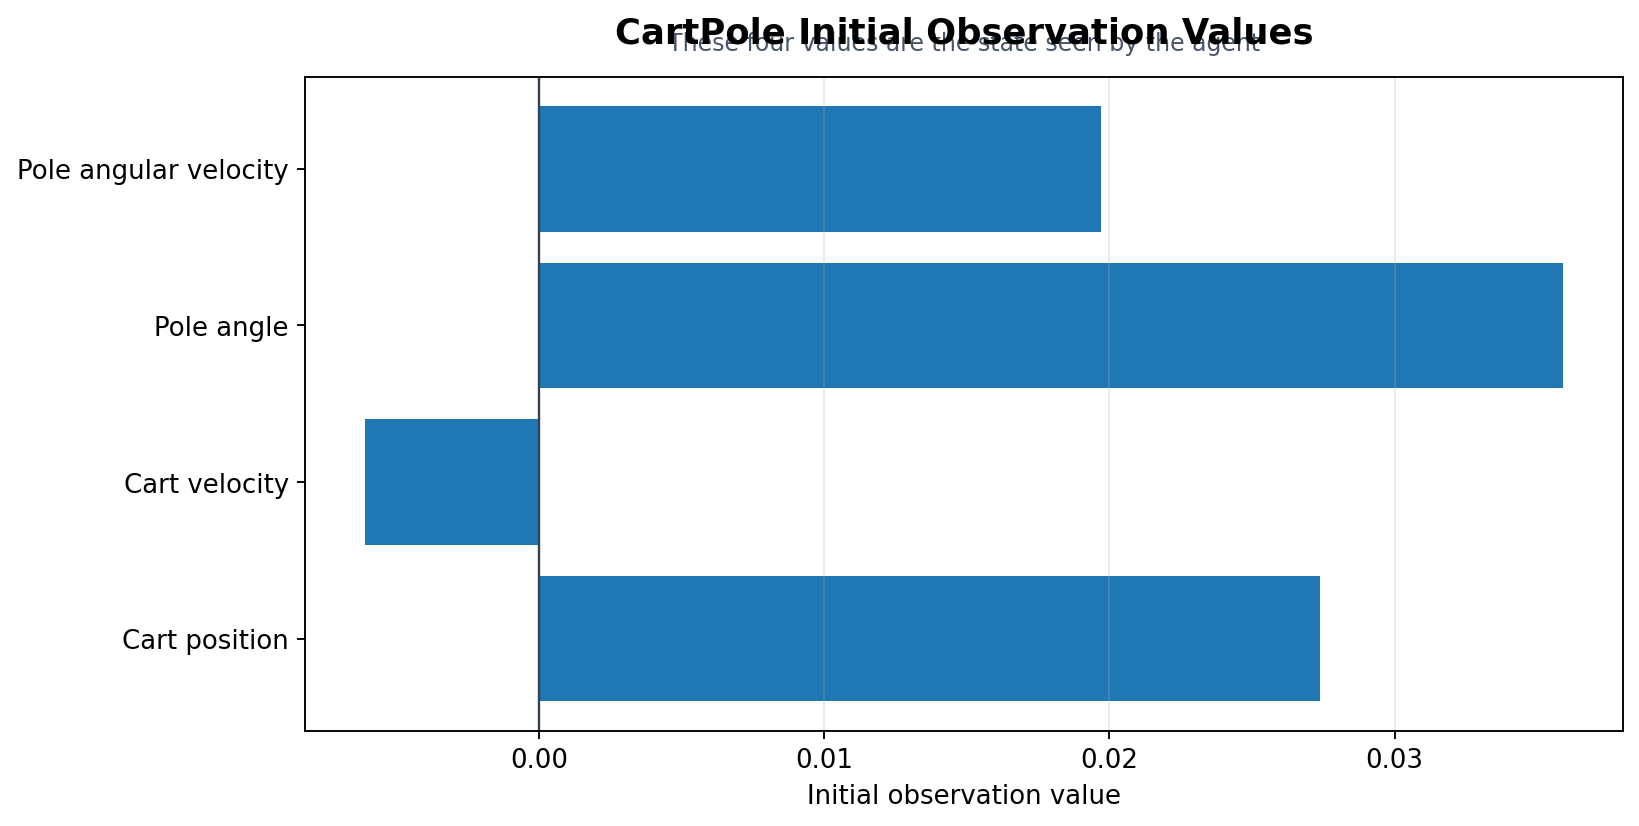

In [3]:
# ============================================================
# CELL 3 — CREATE CARTPOLE AND INSPECT OBSERVATIONS
# ============================================================

# Create the CartPole-v1 environment.
cartpole_env = gym.make("CartPole-v1")

# Reset the environment to get the first observation.
initial_observation, initial_info = cartpole_env.reset(seed=PROJECT_SEED)

# Define readable observation names.
observation_names = ["Cart position", "Cart velocity", "Pole angle", "Pole angular velocity"]

# Define simple meanings for each observation.
observation_meanings = [
    "Where the cart is on the horizontal track.",
    "How fast the cart is moving left or right.",
    "How far the pole is leaning from vertical.",
    "How fast the pole angle is changing."
]

# Build observation table.
observation_table = pd.DataFrame({
    "Observation variable": observation_names,
    "Initial value": np.round(initial_observation, 4),
    "Simple meaning": observation_meanings
})

# Display observation table.
show_table(observation_table, "CartPole observation variables")

# Create chart.
fig, ax = plt.subplots(figsize=(10, 5))

# Plot initial values as horizontal bars.
ax.barh(observation_table["Observation variable"], observation_table["Initial value"])

# Add zero line.
ax.axvline(0, color="#334155", linewidth=1)

# Add title.
ax.set_title("CartPole Initial Observation Values", fontsize=15, fontweight="bold", pad=14)

# Add subtitle.
ax.text(0.5, 1.04, "These four values are the state seen by the agent", transform=ax.transAxes, ha="center", fontsize=10, color="#475569")

# Label axis.
ax.set_xlabel("Initial observation value")

# Add grid.
ax.grid(axis="x", alpha=0.25)

# Save and display chart.
save_and_show_chart(fig, "01_cartpole_initial_observations.png")

# Explain output.
show_conclusion(
    "CartPole state explained",
    "The agent receives four continuous observation values. The pole angle is the easiest value to use in a simple rule, but the DQN later uses all four values to estimate action quality."
)

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 4 — Run 5 random CartPole episodes</h3>
  <p style="margin:0;">The MVD asks for five episodes with random actions. A random policy does not use the state. It simply chooses action 0 or action 1 by chance. This gives us a baseline before using a rule-based or learning-based policy.</p>
  <ul style='margin:10px 0 0 20px;'><li>Reward in CartPole is usually 1 per time step survived.</li><li>Total reward equals how long the pole stayed balanced.</li><li>Random policy is expected to be unstable.</li></ul>
</div>

In [4]:
# ============================================================
# CELL 4 — RUN 5 RANDOM CARTPOLE EPISODES
# ============================================================

# Create list to store total reward per episode.
random_episode_rewards = []

# Run exactly five random episodes.
for episode in range(1, 6):
    # Reset environment at the start of the episode.
    observation, info = cartpole_env.reset(seed=PROJECT_SEED + episode)
    # Start reward counter.
    total_reward = 0
    # Start done flag.
    done = False
    # Continue until the episode ends.
    while not done:
        # Choose a random valid action.
        action = cartpole_env.action_space.sample()
        # Apply action to the environment.
        observation, reward, terminated, truncated, info = cartpole_env.step(action)
        # Add reward to total.
        total_reward += reward
        # Stop if environment ended or timed out.
        done = terminated or truncated
    # Store episode reward.
    random_episode_rewards.append(total_reward)

# Create result table.
random_policy_table = pd.DataFrame({
    "Episode": np.arange(1, 6),
    "Total reward": random_episode_rewards
})

# Display table.
show_table(random_policy_table, "Random policy: 5 CartPole episodes")

# Explain output.
show_conclusion(
    "Random policy baseline completed",
    f"The five random episodes produced rewards from {min(random_episode_rewards):.0f} to {max(random_episode_rewards):.0f}. The mean reward was {np.mean(random_episode_rewards):.2f}. This is the baseline for later comparison."
)

Episode,Total reward
1,16.0
2,48.0
3,13.0
4,21.0
5,12.0


<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 5 — Visualise random-policy rewards</h3>
  <p style="margin:0;">A chart makes the random baseline easier to understand. If the bars vary a lot, it means the random policy is unstable. This is expected because the agent is not using the observation variables.</p>
  <ul style='margin:10px 0 0 20px;'><li>Each bar is one random episode.</li><li>The dashed line is the mean reward.</li><li>Higher reward means the pole survived longer.</li></ul>
</div>

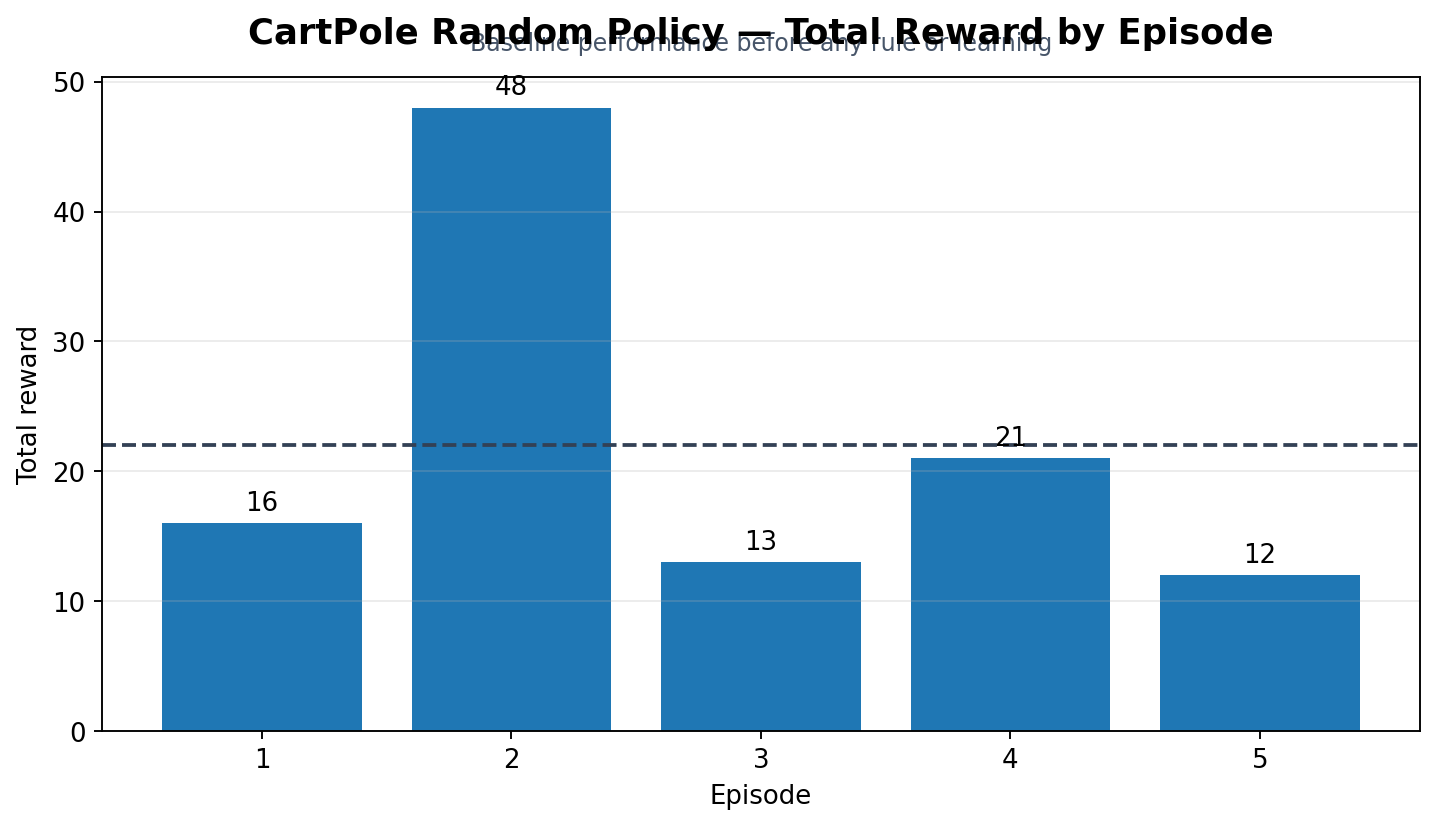

In [5]:
# ============================================================
# CELL 5 — VISUALISE RANDOM-POLICY REWARDS
# ============================================================

# Create figure and axis.
fig, ax = plt.subplots(figsize=(10, 5))

# Draw episode reward bars.
bars = ax.bar(random_policy_table["Episode"].astype(str), random_policy_table["Total reward"])

# Add mean reward line.
ax.axhline(np.mean(random_episode_rewards), linestyle="--", linewidth=1.6, color="#334155")

# Add value labels.
ax.bar_label(bars, fmt="%.0f", padding=3)

# Add title and labels.
ax.set_title("CartPole Random Policy — Total Reward by Episode", fontsize=15, fontweight="bold", pad=14)
ax.text(0.5, 1.04, "Baseline performance before any rule or learning", transform=ax.transAxes, ha="center", fontsize=10, color="#475569")
ax.set_xlabel("Episode")
ax.set_ylabel("Total reward")

# Add clean grid.
ax.grid(axis="y", alpha=0.25)

# Save and display chart.
save_and_show_chart(fig, "02_cartpole_random_policy_rewards.png")

# Explain chart.
show_conclusion(
    "Random-policy chart interpreted",
    f"The random policy average is {np.mean(random_episode_rewards):.2f}. The variation across bars shows that random actions can occasionally survive longer, but there is no controlled strategy."
)

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 6 — Define the angle-based heuristic</h3>
  <p style="margin:0;">The MVD asks for a simple rule: if the pole angle is positive, take action 1; otherwise take action 0. This is not machine learning. It is a human-designed rule that reacts to the most intuitive state variable.</p>
  <ul style='margin:10px 0 0 20px;'><li>Positive pole angle means the pole leans one way.</li><li>Negative or zero angle means the pole leans the other way.</li><li>The rule is simple but ignores three other useful variables.</li></ul>
</div>

In [6]:
# ============================================================
# CELL 6 — DEFINE CARTPOLE HEURISTIC POLICY
# ============================================================

# Define the angle-based heuristic policy.
def angle_heuristic_policy(observation):
    # Read the pole angle from the third observation value.
    pole_angle = observation[2]
    # If the pole leans to the positive side, push right.
    if pole_angle > 0:
        return 1
    # Otherwise push left.
    return 0

# Create rule explanation table.
heuristic_table = pd.DataFrame({
    "Condition": ["Pole angle > 0", "Pole angle <= 0"],
    "Action": [1, 0],
    "Simple meaning": ["Push right", "Push left"]
})

# Display rule.
show_table(heuristic_table, "Rule-based CartPole heuristic")

# Explain rule.
show_conclusion(
    "Heuristic policy defined",
    "The heuristic uses pole angle to react to the direction of the lean. It should be more meaningful than random actions, but it is still limited because it ignores cart position, cart velocity, and pole angular velocity."
)

Condition,Action,Simple meaning
Pole angle > 0,1,Push right
Pole angle <= 0,0,Push left


<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 7 — Evaluate random and heuristic policies over 30 episodes</h3>
  <p style="margin:0;">One episode is not enough to judge an RL policy because results can vary. This cell evaluates both policies over 30 episodes and compares mean, median, and best reward. This gives a more reliable comparison than a single run.</p>
  <ul style='margin:10px 0 0 20px;'><li>Mean reward shows average performance.</li><li>Median reward shows typical performance.</li><li>Best reward shows the strongest episode.</li></ul>
</div>

In [7]:
# ============================================================
# CELL 7 — EVALUATE RANDOM VS HEURISTIC POLICY
# ============================================================

# Set number of evaluation episodes.
EVALUATION_EPISODES = 30

# Define a random policy function.
def random_cartpole_policy(observation):
    # Choose either action 0 or action 1 randomly.
    return cartpole_env.action_space.sample()

# Define reusable policy evaluation function.
def evaluate_cartpole_policy(policy_function, episodes, seed_offset):
    # Create list for episode rewards.
    rewards = []
    # Loop through evaluation episodes.
    for episode in range(episodes):
        # Reset environment.
        observation, info = cartpole_env.reset(seed=PROJECT_SEED + seed_offset + episode)
        # Start reward counter.
        total_reward = 0
        # Start done flag.
        done = False
        # Run one episode.
        while not done:
            # Choose action using the supplied policy.
            action = policy_function(observation)
            # Apply the action.
            observation, reward, terminated, truncated, info = cartpole_env.step(action)
            # Add reward.
            total_reward += reward
            # Update done flag.
            done = terminated or truncated
        # Store reward.
        rewards.append(total_reward)
    # Return all rewards.
    return rewards

# Evaluate random policy.
random_eval_rewards = evaluate_cartpole_policy(random_cartpole_policy, EVALUATION_EPISODES, 100)

# Evaluate heuristic policy.
heuristic_eval_rewards = evaluate_cartpole_policy(angle_heuristic_policy, EVALUATION_EPISODES, 200)

# Build comparison table.
policy_comparison_table = pd.DataFrame({
    "Policy": ["Random policy", "Angle heuristic"],
    "Mean reward": [np.mean(random_eval_rewards), np.mean(heuristic_eval_rewards)],
    "Median reward": [np.median(random_eval_rewards), np.median(heuristic_eval_rewards)],
    "Best reward": [np.max(random_eval_rewards), np.max(heuristic_eval_rewards)]
}).round(2)

# Display comparison table.
show_table(policy_comparison_table, "CartPole policy comparison")

# Explain output.
show_conclusion(
    "Policy comparison completed",
    f"The random policy mean reward is {np.mean(random_eval_rewards):.2f}. The heuristic mean reward is {np.mean(heuristic_eval_rewards):.2f}. This shows whether using pole-angle information improves control."
)

Policy,Mean reward,Median reward,Best reward
Random policy,23.4,17.5,96.0
Angle heuristic,40.5,39.5,56.0


<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 8 — Visualise policy reward distributions</h3>
  <p style="margin:0;">This box plot compares the full reward distribution for random and heuristic policies. It is useful because it shows whether the heuristic is consistently better or only better in a few lucky episodes.</p>
  <ul style='margin:10px 0 0 20px;'><li>Higher median means better typical performance.</li><li>Wider spread means more unstable performance.</li><li>Dots show individual episode rewards.</li></ul>
</div>

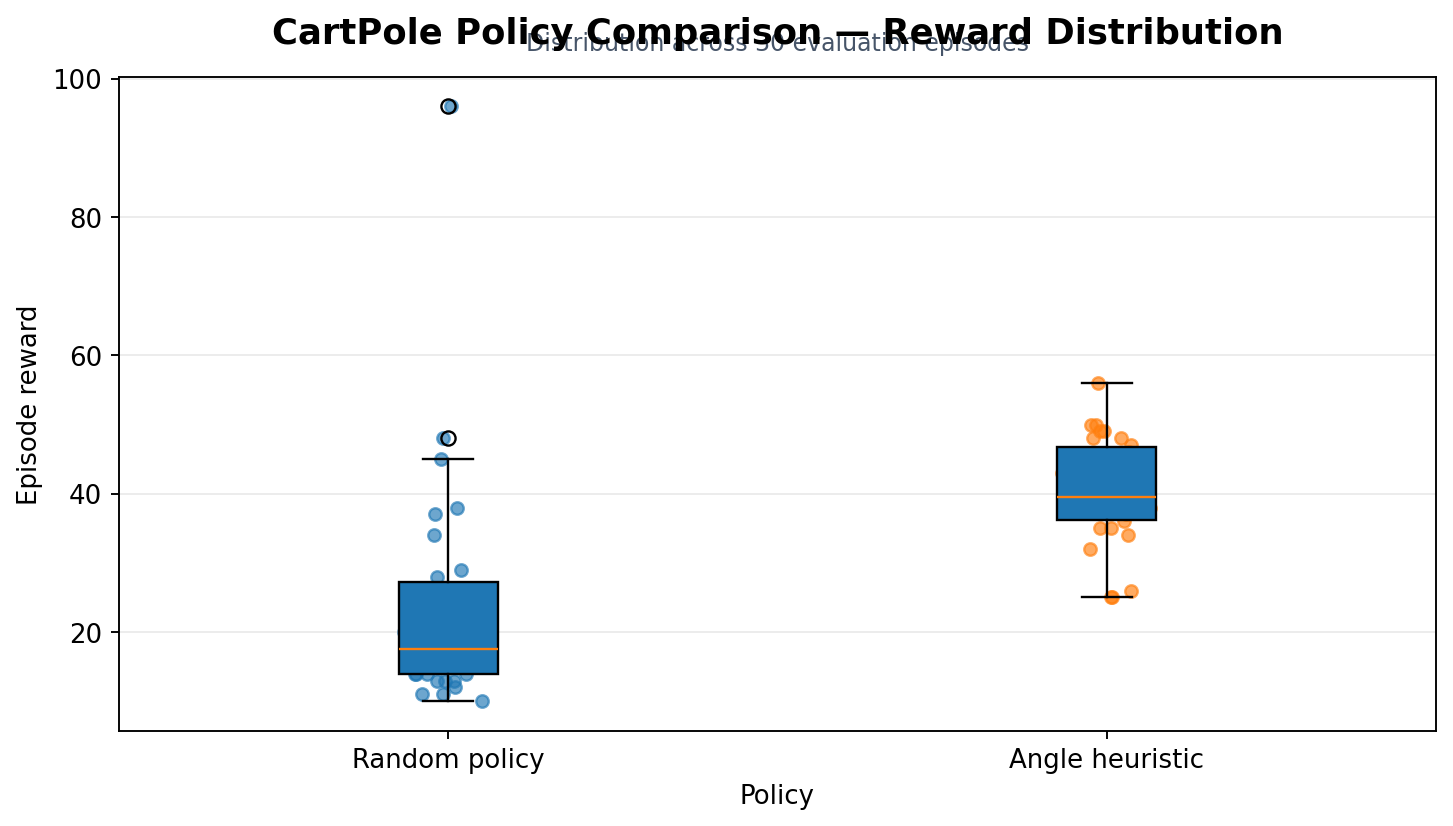

In [8]:
# ============================================================
# CELL 8 — VISUALISE POLICY REWARD DISTRIBUTIONS
# ============================================================

# Prepare reward lists.
boxplot_data = [random_eval_rewards, heuristic_eval_rewards]

# Create figure and axis.
fig, ax = plt.subplots(figsize=(10, 5))

# Draw box plot.
ax.boxplot(boxplot_data, labels=["Random policy", "Angle heuristic"], patch_artist=True)

# Add individual episode points.
for x_pos, rewards in enumerate(boxplot_data, start=1):
    # Add jitter for point visibility.
    jitter = np.random.normal(0, 0.035, len(rewards))
    # Plot individual rewards.
    ax.scatter(np.full(len(rewards), x_pos) + jitter, rewards, alpha=0.65, s=28)

# Add title and labels.
ax.set_title("CartPole Policy Comparison — Reward Distribution", fontsize=15, fontweight="bold", pad=14)
ax.text(0.5, 1.04, "Distribution across 30 evaluation episodes", transform=ax.transAxes, ha="center", fontsize=10, color="#475569")
ax.set_xlabel("Policy")
ax.set_ylabel("Episode reward")

# Add grid.
ax.grid(axis="y", alpha=0.25)

# Save and display chart.
save_and_show_chart(fig, "03_cartpole_policy_reward_distribution.png")

# Explain chart.
show_conclusion(
    "Policy distribution chart interpreted",
    "The chart shows both average tendency and variability. A better policy should usually have a higher box and fewer very low-reward episodes."
)

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 9 — Visualise policy summary metrics</h3>
  <p style="margin:0;">This chart summarizes the random-vs-heuristic comparison using mean, median, and best reward. It gives a quick BI-style view of which policy performs better.</p>
  <ul style='margin:10px 0 0 20px;'><li>Mean = average performance.</li><li>Median = typical performance.</li><li>Best = strongest episode.</li></ul>
</div>

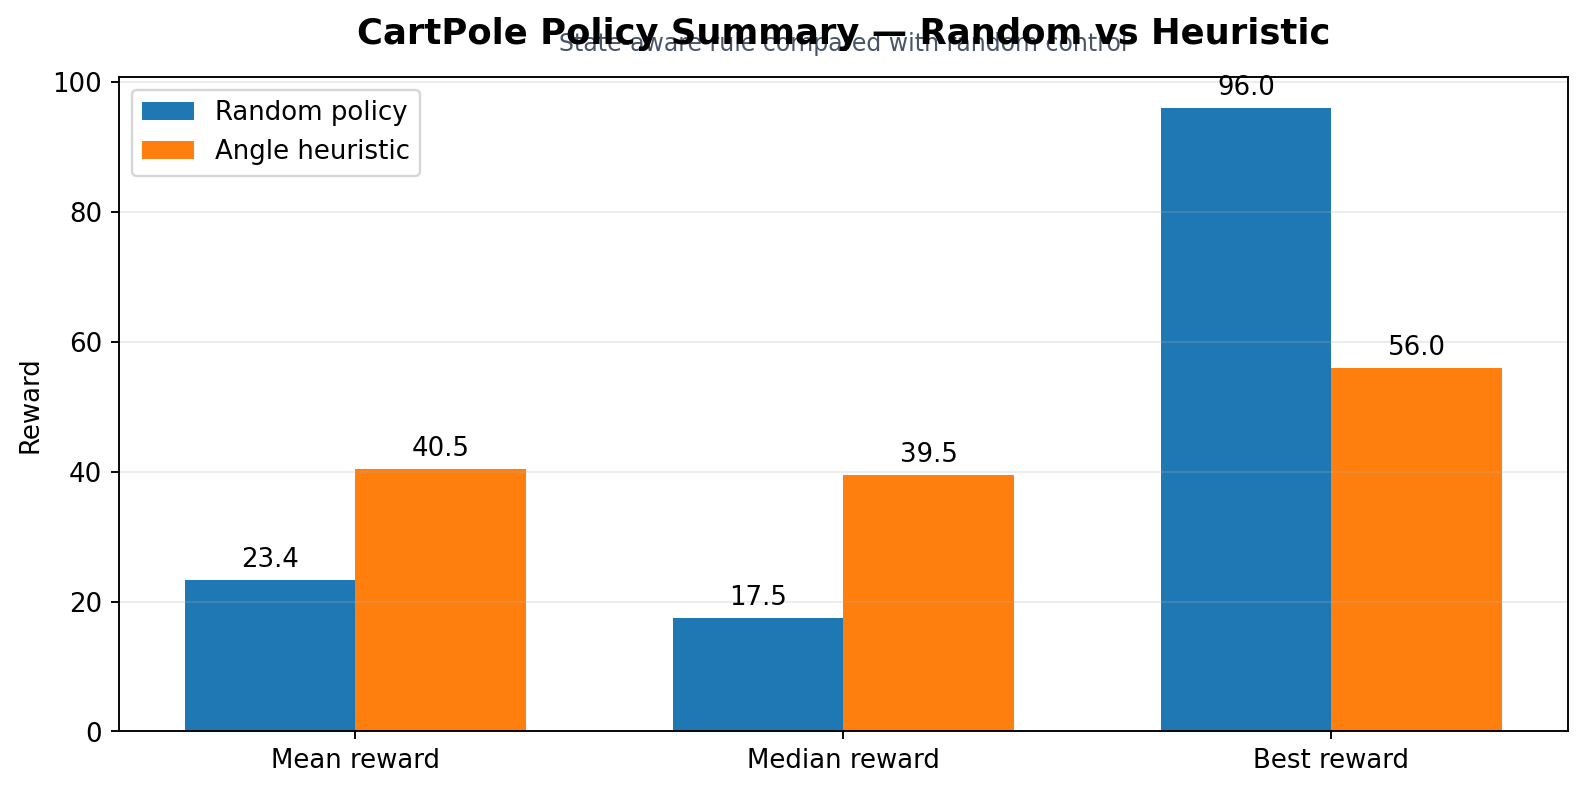

In [9]:
# ============================================================
# CELL 9 — VISUALISE POLICY SUMMARY METRICS
# ============================================================

# Choose metrics to plot.
metrics = ["Mean reward", "Median reward", "Best reward"]

# Create bar positions.
x = np.arange(len(metrics))

# Set grouped-bar width.
width = 0.35

# Create figure and axis.
fig, ax = plt.subplots(figsize=(11, 5))

# Plot random policy bars.
bars_random = ax.bar(x - width / 2, policy_comparison_table.loc[0, metrics], width, label="Random policy")

# Plot heuristic policy bars.
bars_heuristic = ax.bar(x + width / 2, policy_comparison_table.loc[1, metrics], width, label="Angle heuristic")

# Add bar labels.
ax.bar_label(bars_random, fmt="%.1f", padding=3)
ax.bar_label(bars_heuristic, fmt="%.1f", padding=3)

# Add title and labels.
ax.set_title("CartPole Policy Summary — Random vs Heuristic", fontsize=15, fontweight="bold", pad=14)
ax.text(0.5, 1.04, "State-aware rule compared with random control", transform=ax.transAxes, ha="center", fontsize=10, color="#475569")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Reward")
ax.legend()

# Add grid.
ax.grid(axis="y", alpha=0.25)

# Save and display chart.
save_and_show_chart(fig, "04_cartpole_policy_summary_metrics.png")

# Explain chart.
show_conclusion(
    "Policy summary chart interpreted",
    f"The heuristic mean reward is {policy_comparison_table.loc[1, 'Mean reward']:.2f}. The random mean reward is {policy_comparison_table.loc[0, 'Mean reward']:.2f}. This gives a clear comparison for the MVD."
)

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 10 — Explain done=True</h3>
  <p style="margin:0;">In Gymnasium, an episode ends when either <code>terminated=True</code> or <code>truncated=True</code>. We often combine them into <code>done = terminated or truncated</code>. This tells the training loop to stop the current episode and reset the environment.</p>
  <ul style='margin:10px 0 0 20px;'><li>terminated: the environment naturally ended.</li><li>truncated: a time limit or cutoff ended the episode.</li><li>done: either one happened.</li></ul>
</div>

In [10]:
# ============================================================
# CELL 10 — EXPLAIN DONE=TRUE
# ============================================================

# Reset environment.
observation, info = cartpole_env.reset(seed=PROJECT_SEED + 999)

# Start counters.
done_demo_reward = 0
done_demo_steps = 0

# Start end flags.
terminated = False
truncated = False

# Run one heuristic episode.
while not (terminated or truncated):
    # Select action using heuristic.
    action = angle_heuristic_policy(observation)
    # Step environment.
    observation, reward, terminated, truncated, info = cartpole_env.step(action)
    # Add reward.
    done_demo_reward += reward
    # Count step.
    done_demo_steps += 1

# Combine terminal flags.
done_value = terminated or truncated

# Build explanation table.
done_table = pd.DataFrame({
    "Item": ["Steps completed", "Total reward", "terminated", "truncated", "done"],
    "Value": [done_demo_steps, done_demo_reward, terminated, truncated, done_value],
    "Meaning": [
        "Number of steps before the episode stopped.",
        "Reward earned before stopping.",
        "True if the task naturally ended.",
        "True if a time limit ended the episode.",
        "True when terminated or truncated is true."
    ]
})

# Display table.
show_table(done_table, "Understanding done=True")

# Explain output.
show_conclusion(
    "done=True explained",
    f"This episode stopped after {done_demo_steps} steps. After done=True, the environment must be reset before starting a new episode."
)

Item,Value,Meaning
Steps completed,25,Number of steps before the episode stopped.
Total reward,25.0,Reward earned before stopping.
terminated,True,True if the task naturally ended.
truncated,False,True if a time limit ended the episode.
done,True,True when terminated or truncated is true.


<div style="font-family:Arial, sans-serif; background:#f8fafc; color:#111827; padding:20px 24px; border-left:6px solid #0f172a; border-radius:10px; line-height:1.65;">
  <h2 style="margin:0 0 8px 0; color:#0f172a;">Section 2 — Intermediate MVD: Q-Learning on FrozenLake-v1</h2>
  <p style="margin:0;">FrozenLake is a small grid-world problem, so tabular Q-Learning is suitable. The agent stores one Q-value for every state-action pair and updates those values from experience.</p>
</div>

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 11 — Create deterministic FrozenLake and initialise Q-table</h3>
  <p style="margin:0;">FrozenLake has 16 states and 4 actions. In the deterministic version, actions behave predictably. This makes it easier to see Q-Learning work before adding slippery stochastic transitions.</p>
  <ul style='margin:10px 0 0 20px;'><li>State = current grid cell.</li><li>Action = left, down, right or up.</li><li>Q-table shape = states × actions.</li></ul>
</div>

In [11]:
# ============================================================
# CELL 11 — CREATE FROZENLAKE AND INITIAL Q-TABLE
# ============================================================

# Create deterministic FrozenLake.
frozenlake_deterministic_env = gym.make("FrozenLake-v1", is_slippery=False)

# Read number of states.
n_states = frozenlake_deterministic_env.observation_space.n

# Read number of actions.
n_actions = frozenlake_deterministic_env.action_space.n

# Define action labels.
action_labels = ["Left", "Down", "Right", "Up"]

# Create initial Q-table.
initial_q_table = np.zeros((n_states, n_actions))

# Create summary table.
frozenlake_table = pd.DataFrame({
    "Item": ["Environment", "Slippery transitions", "Number of states", "Number of actions", "Q-table shape"],
    "Value": ["FrozenLake-v1", False, n_states, n_actions, f"{n_states} × {n_actions}"],
    "Meaning": ["Grid-world task", "Actions are predictable", "Each grid cell is a state", "Available moves", "One value per state-action pair"]
})

# Display table.
show_table(frozenlake_table, "FrozenLake deterministic setup")

# Explain output.
show_conclusion(
    "FrozenLake setup completed",
    f"The environment has {n_states} states and {n_actions} actions, so the Q-table has {n_states * n_actions} learnable values."
)

Item,Value,Meaning
Environment,FrozenLake-v1,Grid-world task
Slippery transitions,False,Actions are predictable
Number of states,16,Each grid cell is a state
Number of actions,4,Available moves
Q-table shape,16 × 4,One value per state-action pair


<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 12 — Define epsilon-greedy action selection</h3>
  <p style="margin:0;">Epsilon-greedy is the exploration strategy. With probability epsilon, the agent explores using a random action. Otherwise, it exploits by choosing the best action from the current Q-table. This prevents the agent from getting stuck too early.</p>
  <ul style='margin:10px 0 0 20px;'><li>Explore = try something random.</li><li>Exploit = use the best known action.</li><li>Epsilon slowly decreases during training.</li></ul>
</div>

In [12]:
# ============================================================
# CELL 12 — DEFINE EPSILON-GREEDY ACTION SELECTION
# ============================================================

# Define epsilon-greedy action selection.
def choose_epsilon_greedy_action(q_table, state, epsilon, env):
    # Draw a random value between 0 and 1.
    random_value = np.random.random()
    # Explore if random value is less than epsilon.
    if random_value < epsilon:
        return env.action_space.sample()
    # Exploit by taking the best Q-table action.
    return int(np.argmax(q_table[state]))

# Show logic table.
epsilon_table = pd.DataFrame({
    "Decision mode": ["Explore", "Exploit"],
    "Condition": ["random number < epsilon", "random number >= epsilon"],
    "Action": ["Random action", "Best Q-table action"]
})

# Display table.
show_table(epsilon_table, "Epsilon-greedy logic")

# Explain output.
show_conclusion(
    "Epsilon-greedy helper completed",
    "This helper gives the agent both curiosity and discipline: it explores enough to learn, then gradually relies more on the Q-table."
)

Decision mode,Condition,Action
Explore,random number < epsilon,Random action
Exploit,random number >= epsilon,Best Q-table action


<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 13 — Define Q-value update and training helpers</h3>
  <p style="margin:0;">The Q-Learning update changes one Q-table value after each experience. The agent compares the old estimate with a new target: immediate reward plus discounted future value. Over many episodes, useful actions receive higher Q-values.</p>
  <ul style='margin:10px 0 0 20px;'><li>alpha controls update strength.</li><li>gamma controls future-reward importance.</li><li>rolling mean over 100 episodes tracks learning progress.</li></ul>
</div>

In [13]:
# ============================================================
# CELL 13 — DEFINE Q-LEARNING UPDATE HELPERS
# ============================================================

# Define rolling mean helper.
def rolling_mean(values, window):
    # Convert values to pandas Series.
    value_series = pd.Series(values)
    # Return rolling mean as NumPy array.
    return value_series.rolling(window=window, min_periods=1).mean().to_numpy()

# Define Q-value update.
def update_q_value(q_table, state, action, reward, next_state, alpha, gamma):
    # Read old Q-value.
    old_q = q_table[state, action]
    # Read best future Q-value.
    best_future_q = np.max(q_table[next_state])
    # Calculate target Q-value.
    target_q = reward + gamma * best_future_q
    # Move old Q-value toward target.
    q_table[state, action] = old_q + alpha * (target_q - old_q)
    # Return updated table.
    return q_table

# Explain helpers.
show_conclusion(
    "Q-Learning update helpers completed",
    "The helper functions now support the core Q-Learning logic: update one Q-table value after each transition and smooth rewards for learning-curve interpretation."
)

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 14 — Define Q-Learning training function</h3>
  <p style="margin:0;">This function runs many FrozenLake episodes. In every step, the agent chooses an action with epsilon-greedy logic, observes the reward and next state, updates the Q-table, and continues until the episode ends.</p>
  <ul style='margin:10px 0 0 20px;'><li>The MVD requires 10,000 episodes.</li><li>The function returns Q-table, rewards and rolling reward.</li><li>The same function is reused for deterministic and slippery FrozenLake.</li></ul>
</div>

In [14]:
# ============================================================
# CELL 14 — DEFINE Q-LEARNING TRAINING FUNCTION
# ============================================================

# Define Q-Learning training function.
def train_q_learning(env, episodes=10000, alpha=0.1, gamma=0.9, epsilon_start=1.0, epsilon_min=0.05, epsilon_decay=0.999):
    # Create empty Q-table.
    q_table = np.zeros((env.observation_space.n, env.action_space.n))
    # Create reward history.
    rewards = []
    # Start epsilon.
    epsilon = epsilon_start
    # Loop through episodes.
    for episode in range(episodes):
        # Reset environment.
        state, info = env.reset(seed=PROJECT_SEED + episode)
        # Start reward counter.
        total_reward = 0
        # Start done flag.
        done = False
        # Run one episode.
        while not done:
            # Choose action.
            action = choose_epsilon_greedy_action(q_table, state, epsilon, env)
            # Step environment.
            next_state, reward, terminated, truncated, info = env.step(action)
            # Update Q-table.
            q_table = update_q_value(q_table, state, action, reward, next_state, alpha, gamma)
            # Move to next state.
            state = next_state
            # Add reward.
            total_reward += reward
            # Update done flag.
            done = terminated or truncated
        # Store reward.
        rewards.append(total_reward)
        # Decay epsilon.
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
    # Calculate rolling reward.
    rolling_100 = rolling_mean(rewards, 100)
    # Return outputs.
    return q_table, rewards, rolling_100

# Explain function.
show_conclusion(
    "Q-Learning training function ready",
    "The training function is ready. It will learn a Q-table from 10,000 episodes and produce reward histories for the required charts."
)

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 15 — Train deterministic FrozenLake for 10,000 episodes</h3>
  <p style="margin:0;">This cell completes the main Intermediate MVD requirement. The deterministic environment is easier because the same action has a predictable result. The final last-100 mean reward is interpreted as the recent goal-reaching success rate.</p>
  <ul style='margin:10px 0 0 20px;'><li>Training length: 10,000 episodes.</li><li>Reward 1 means the goal was reached.</li><li>Final last-100 reward shows recent success rate.</li></ul>
</div>

In [15]:
# ============================================================
# CELL 15 — TRAIN DETERMINISTIC FROZENLAKE
# ============================================================

# Train deterministic FrozenLake.
det_q_table, det_rewards, det_rolling_100 = train_q_learning(
    env=frozenlake_deterministic_env,
    episodes=10000,
    alpha=0.1,
    gamma=0.9
)

# Calculate recent mean reward.
det_final_mean_100 = np.mean(det_rewards[-100:])

# Count total successes.
det_total_successes = int(np.sum(det_rewards))

# Build summary table.
det_summary_table = pd.DataFrame({
    "Metric": ["Training episodes", "Final mean reward: last 100", "Total successful episodes"],
    "Value": [10000, round(det_final_mean_100, 3), det_total_successes]
})

# Display table.
show_table(det_summary_table, "Deterministic FrozenLake Q-Learning summary")

# Explain output.
show_conclusion(
    "Deterministic Q-Learning training completed",
    f"The final last-100 mean reward is {det_final_mean_100:.3f}. Since FrozenLake reward is 1 only at the goal, this means the agent recently reached the goal in about {det_final_mean_100 * 100:.1f}% of episodes."
)

Metric,Value
Training episodes,10000.00
Final mean reward: last 100,0.92
Total successful episodes,8564.00


<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 16 — Plot mean reward over last 100 episodes</h3>
  <p style="margin:0;">This line chart is the required Q-Learning learning curve. A rising rolling reward means the Q-table is improving. A high flat line means the learned policy has become stable.</p>
  <ul style='margin:10px 0 0 20px;'><li>MVD-required plot.</li><li>Rolling window = 100 episodes.</li><li>Higher curve means more frequent goal success.</li></ul>
</div>

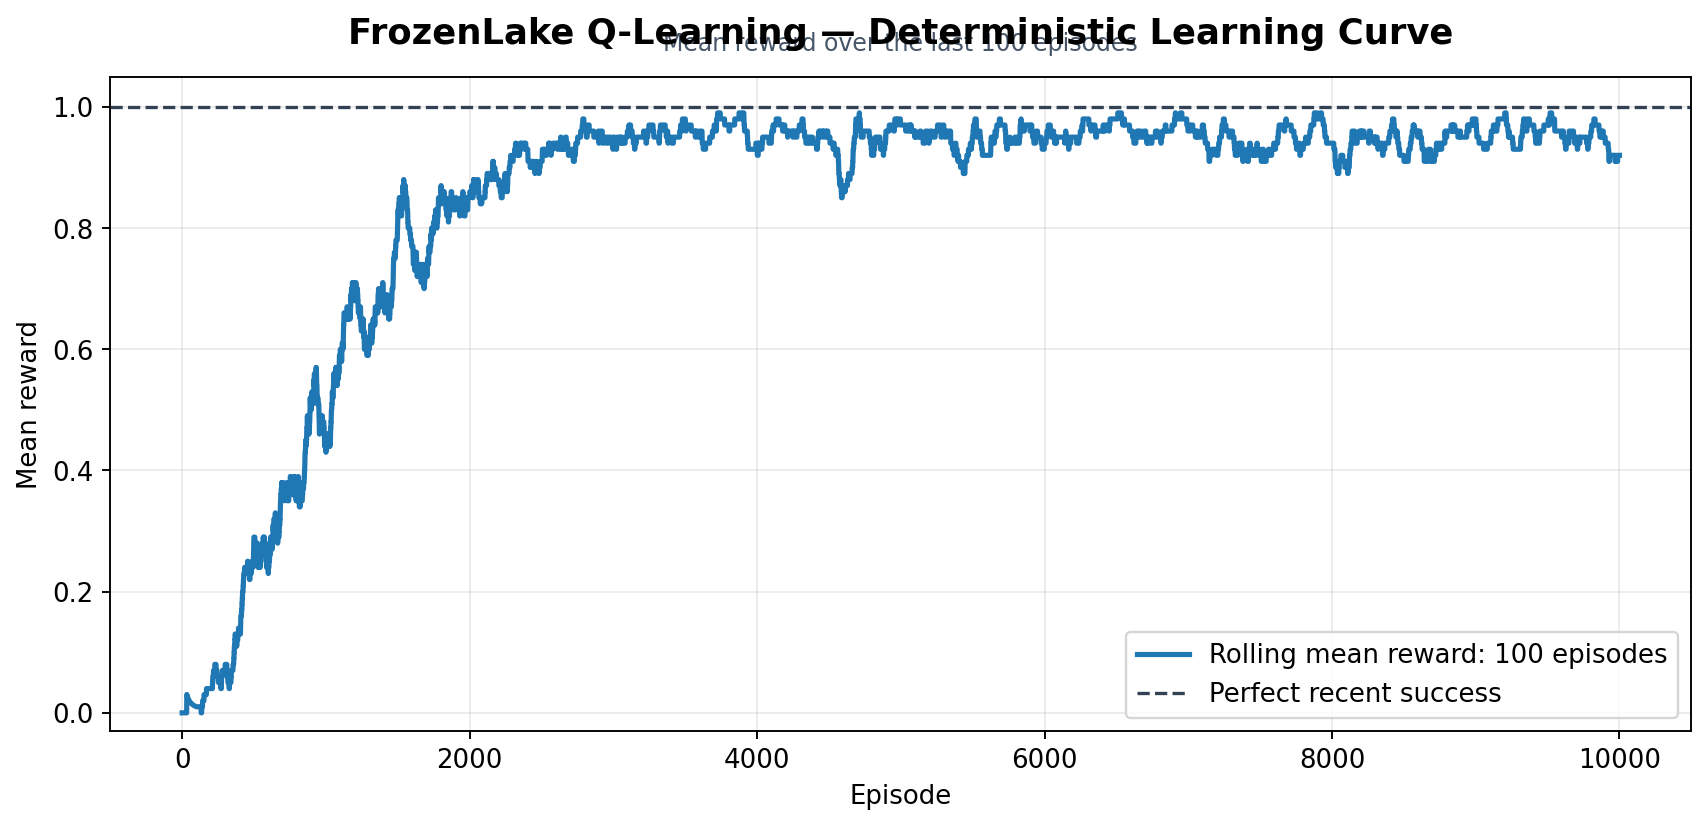

In [16]:
# ============================================================
# CELL 16 — PLOT DETERMINISTIC FROZENLAKE LEARNING CURVE
# ============================================================

# Create episode axis.
episode_axis = np.arange(1, len(det_rolling_100) + 1)

# Create chart.
fig, ax = plt.subplots(figsize=(12, 5))

# Plot rolling mean reward.
ax.plot(episode_axis, det_rolling_100, linewidth=2.2, label="Rolling mean reward: 100 episodes")

# Add perfect performance line.
ax.axhline(1.0, linestyle="--", linewidth=1.4, color="#334155", label="Perfect recent success")

# Add title and labels.
ax.set_title("FrozenLake Q-Learning — Deterministic Learning Curve", fontsize=15, fontweight="bold", pad=14)
ax.text(0.5, 1.04, "Mean reward over the last 100 episodes", transform=ax.transAxes, ha="center", fontsize=10, color="#475569")
ax.set_xlabel("Episode")
ax.set_ylabel("Mean reward")
ax.set_ylim(-0.03, 1.05)
ax.legend(loc="lower right")
ax.grid(alpha=0.25)

# Save and display chart.
save_and_show_chart(fig, "05_frozenlake_deterministic_learning_curve.png")

# Explain chart.
show_conclusion(
    "Deterministic learning curve interpreted",
    f"The curve ends at {det_rolling_100[-1]:.3f}. This shows that the Q-table learned a strong deterministic FrozenLake policy by the end of training."
)

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 17 — Visualise learned FrozenLake policy</h3>
  <p style="margin:0;">A Q-table is hard to read directly. This grid converts the best action in each state into an arrow. It shows what the trained agent would do from each grid cell.</p>
  <ul style='margin:10px 0 0 20px;'><li>Each cell is one state.</li><li>Each arrow is the best action.</li><li>This makes the learned policy understandable.</li></ul>
</div>

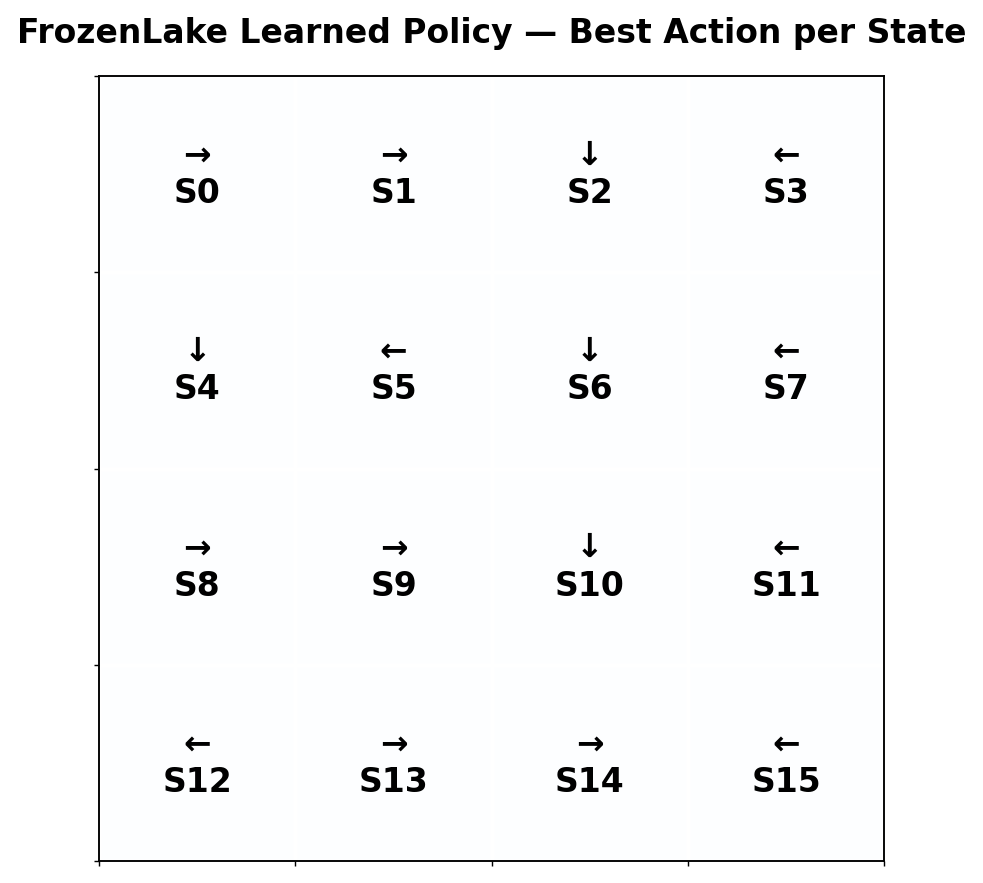

In [17]:
# ============================================================
# CELL 17 — VISUALISE LEARNED FROZENLAKE POLICY
# ============================================================

# Choose best action per state.
best_actions = np.argmax(det_q_table, axis=1)

# Convert action numbers to arrows.
action_arrows = np.array(["←", "↓", "→", "↑"])

# Reshape arrows into 4x4 grid.
policy_grid = action_arrows[best_actions].reshape(4, 4)

# Create chart.
fig, ax = plt.subplots(figsize=(6, 6))

# Draw background grid.
ax.imshow(np.zeros((4, 4)), cmap="Blues", alpha=0.18)

# Add arrows and state numbers.
for row in range(4):
    for col in range(4):
        state_number = row * 4 + col
        ax.text(col, row, f"{policy_grid[row, col]}\nS{state_number}", ha="center", va="center", fontsize=14, fontweight="bold")

# Add grid lines.
ax.set_xticks(np.arange(-0.5, 4, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 4, 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("FrozenLake Learned Policy — Best Action per State", fontsize=14, fontweight="bold", pad=14)

# Save and display chart.
save_and_show_chart(fig, "06_frozenlake_learned_policy_grid.png")

# Explain chart.
show_conclusion(
    "Learned policy grid interpreted",
    "The arrows translate the Q-table into a policy map. This is easier to understand than raw Q-values because it directly shows the action the agent would choose in each state."
)

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 18 — Test alpha and gamma combinations</h3>
  <p style="margin:0;">The MVD asks us to vary alpha and gamma. Alpha controls how aggressively new experience updates the Q-table. Gamma controls how much future reward matters. We measure convergence speed by finding when rolling reward first reaches 0.8.</p>
  <ul style='margin:10px 0 0 20px;'><li>alpha values: 0.1, 0.5, 0.9.</li><li>gamma values: 0.7, 0.9, 0.99.</li><li>Fastest convergence = lowest episode number.</li></ul>
</div>

In [18]:
# ============================================================
# CELL 18 — ALPHA/GAMMA EXPERIMENT
# ============================================================

# Define alpha values.
alpha_values = [0.1, 0.5, 0.9]

# Define gamma values.
gamma_values = [0.7, 0.9, 0.99]

# Set experiment length for the parameter grid.
EXPERIMENT_EPISODES = 5000

# Create result list.
experiment_results = []

# Run all combinations.
for alpha_value in alpha_values:
    for gamma_value in gamma_values:
        # Create fresh environment.
        env = gym.make("FrozenLake-v1", is_slippery=False)
        # Train model.
        q_table, rewards, rolling = train_q_learning(env, episodes=EXPERIMENT_EPISODES, alpha=alpha_value, gamma=gamma_value)
        # Find first episode where rolling mean reaches 0.8.
        reached = np.where(rolling >= 0.8)[0]
        # Convert to episode number or NaN.
        convergence_episode = int(reached[0] + 1) if len(reached) > 0 else np.nan
        # Store result.
        experiment_results.append({
            "alpha": alpha_value,
            "gamma": gamma_value,
            "convergence_episode_at_0.8": convergence_episode,
            "final_mean_reward_last_100": round(float(np.mean(rewards[-100:])), 3)
        })
        # Close environment.
        env.close()

# Create DataFrame.
q_experiment_df = pd.DataFrame(experiment_results)

# Sort by convergence speed.
q_experiment_df = q_experiment_df.sort_values("convergence_episode_at_0.8", na_position="last")

# Display table.
show_table(q_experiment_df, "Alpha/Gamma experiment results")

# Extract fastest row.
best_q_combo = q_experiment_df.iloc[0]

# Explain output.
show_conclusion(
    "Alpha/Gamma experiment completed",
    f"Using 5,000 episodes per parameter setting, the fastest combination was alpha={best_q_combo['alpha']} and gamma={best_q_combo['gamma']}, reaching rolling reward ≥ 0.8 around episode {int(best_q_combo['convergence_episode_at_0.8'])}."
)

alpha,gamma,convergence_episode_at_0.8,final_mean_reward_last_100
0.5,0.99,1434,0.96
0.9,0.70,1450,0.93
0.9,0.90,1527,0.96
0.9,0.99,1563,0.99
0.1,0.99,1572,0.92
0.1,0.90,1593,0.97
0.5,0.90,1609,0.95
0.5,0.70,1624,0.95
0.1,0.70,1690,0.94


<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 19 — Visualise alpha/gamma convergence speed</h3>
  <p style="margin:0;">This heatmap compares the full alpha/gamma experiment. It is easier to understand than a table because low and high convergence episodes are visible immediately.</p>
  <ul style='margin:10px 0 0 20px;'><li>Rows show alpha.</li><li>Columns show gamma.</li><li>Lower values mean faster convergence.</li></ul>
</div>

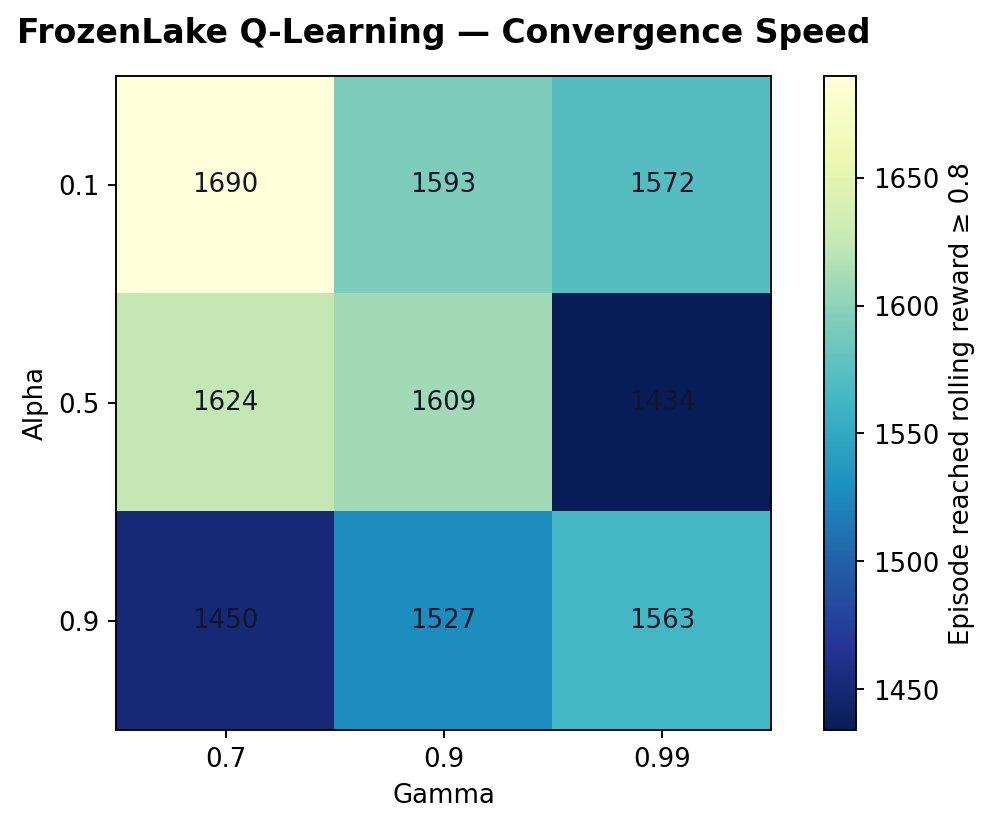

In [19]:
# ============================================================
# CELL 19 — ALPHA/GAMMA CONVERGENCE HEATMAP
# ============================================================

# Pivot data for heatmap.
convergence_pivot = q_experiment_df.pivot(index="alpha", columns="gamma", values="convergence_episode_at_0.8")

# Create chart.
fig, ax = plt.subplots(figsize=(8, 5))

# Draw heatmap.
image = ax.imshow(convergence_pivot.values, cmap="YlGnBu_r")

# Set tick positions and labels.
ax.set_xticks(np.arange(len(convergence_pivot.columns)))
ax.set_xticklabels(convergence_pivot.columns)
ax.set_yticks(np.arange(len(convergence_pivot.index)))
ax.set_yticklabels(convergence_pivot.index)

# Annotate cells.
for row in range(convergence_pivot.shape[0]):
    for col in range(convergence_pivot.shape[1]):
        value = convergence_pivot.values[row, col]
        label = "N/A" if pd.isna(value) else f"{value:.0f}"
        ax.text(col, row, label, ha="center", va="center", color="#0f172a", fontsize=11)

# Add color bar.
fig.colorbar(image, ax=ax, label="Episode reached rolling reward ≥ 0.8")

# Add title and labels.
ax.set_title("FrozenLake Q-Learning — Convergence Speed", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Gamma")
ax.set_ylabel("Alpha")

# Save and display chart.
save_and_show_chart(fig, "07_frozenlake_alpha_gamma_convergence_heatmap.png")

# Explain chart.
show_conclusion(
    "Convergence heatmap interpreted",
    "The heatmap identifies which alpha/gamma setting learned fastest. Lower numbers are better because the agent reached strong recent performance earlier."
)

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 20 — Visualise final reward by alpha/gamma setting</h3>
  <p style="margin:0;">Fast convergence is not the only thing that matters. This chart shows the final mean reward for each alpha/gamma setting. A good parameter combination should ideally learn quickly and finish with high reward.</p>
  <ul style='margin:10px 0 0 20px;'><li>Final reward checks stability.</li><li>Convergence checks speed.</li><li>Both are useful for model selection.</li></ul>
</div>

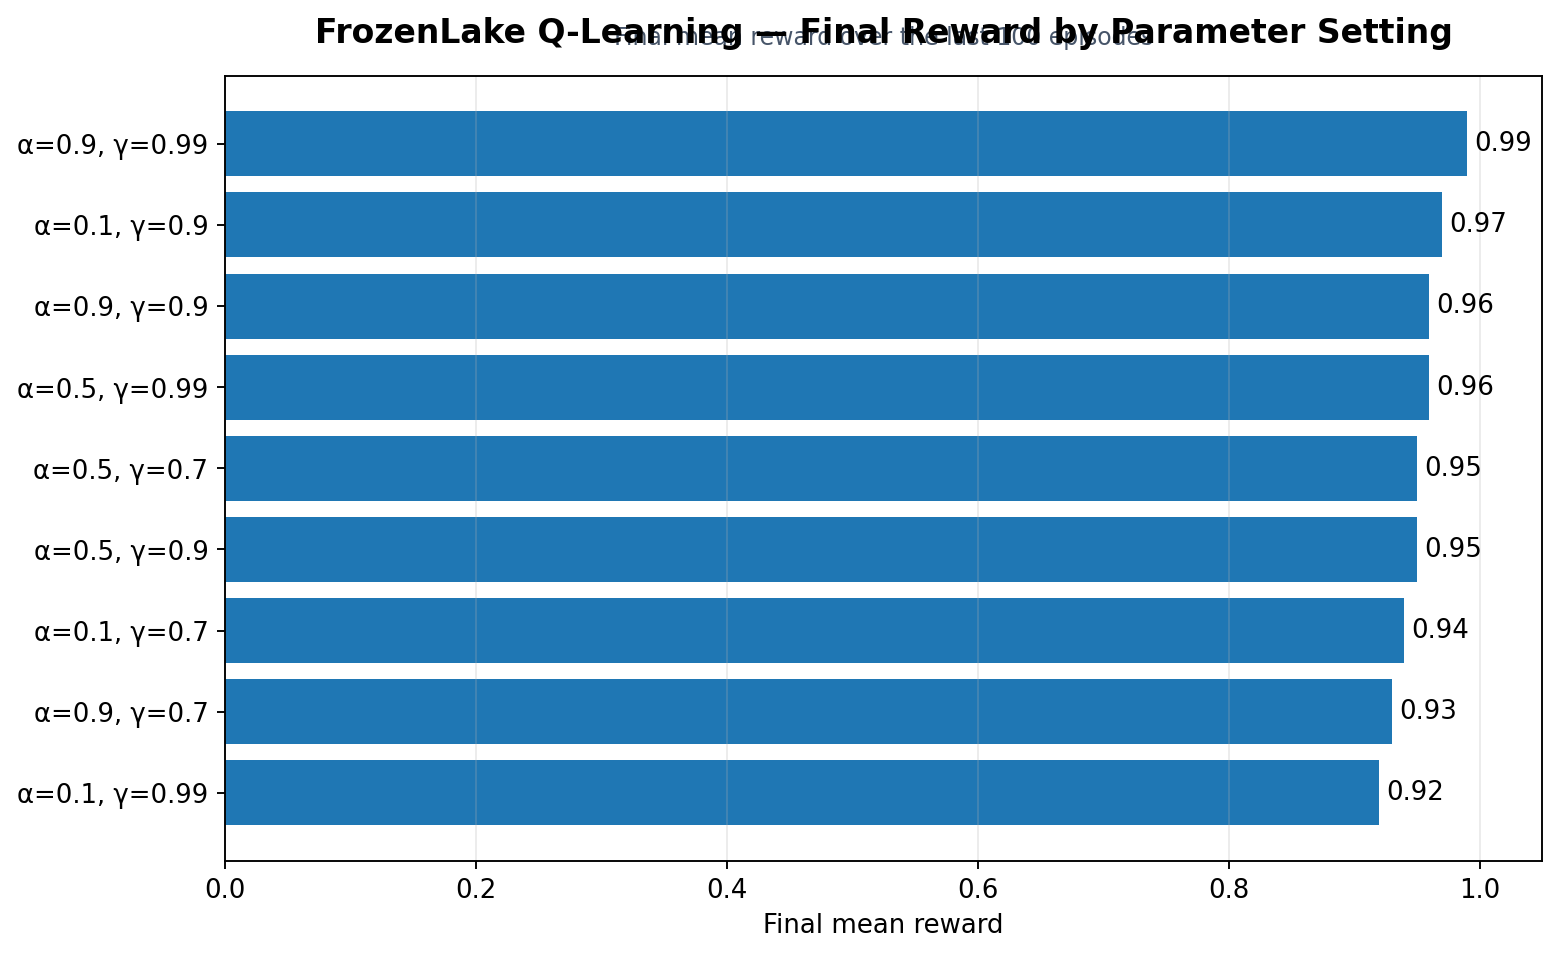

In [20]:
# ============================================================
# CELL 20 — FINAL REWARD BY ALPHA/GAMMA SETTING
# ============================================================

# Create label for each setting.
q_experiment_df["Setting"] = q_experiment_df.apply(lambda row: f"α={row['alpha']}, γ={row['gamma']}", axis=1)

# Sort by final reward.
final_plot_df = q_experiment_df.sort_values("final_mean_reward_last_100")

# Create chart.
fig, ax = plt.subplots(figsize=(10, 6))

# Plot horizontal bars.
bars = ax.barh(final_plot_df["Setting"], final_plot_df["final_mean_reward_last_100"])

# Add labels.
ax.bar_label(bars, fmt="%.2f", padding=3)

# Add title and labels.
ax.set_title("FrozenLake Q-Learning — Final Reward by Parameter Setting", fontsize=14, fontweight="bold", pad=14)
ax.text(0.5, 1.04, "Final mean reward over the last 100 episodes", transform=ax.transAxes, ha="center", fontsize=10, color="#475569")
ax.set_xlabel("Final mean reward")
ax.set_xlim(0, 1.05)
ax.grid(axis="x", alpha=0.25)

# Save and display chart.
save_and_show_chart(fig, "08_frozenlake_alpha_gamma_final_reward.png")

# Explain chart.
show_conclusion(
    "Final alpha/gamma performance interpreted",
    "This chart checks whether the fastest parameter setting also ends with strong performance. It supports a more complete answer than convergence speed alone."
)

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 21 — Train Q-Learning on slippery FrozenLake</h3>
  <p style="margin:0;">The slippery version introduces stochastic transitions. This means that the action chosen by the agent may not lead exactly where expected. The agent now learns in a noisier and less predictable environment.</p>
  <ul style='margin:10px 0 0 20px;'><li>Deterministic: action result is predictable.</li><li>Slippery: action result can vary.</li><li>Stochastic environments usually learn more slowly.</li></ul>
</div>

In [21]:
# ============================================================
# CELL 21 — TRAIN SLIPPERY FROZENLAKE
# ============================================================

# Create slippery FrozenLake.
frozenlake_slippery_env = gym.make("FrozenLake-v1", is_slippery=True)

# Train Q-Learning on slippery environment.
slip_q_table, slip_rewards, slip_rolling_100 = train_q_learning(
    env=frozenlake_slippery_env,
    episodes=10000,
    alpha=0.1,
    gamma=0.9
)

# Calculate final recent reward.
slip_final_mean_100 = np.mean(slip_rewards[-100:])

# Count successes.
slip_total_successes = int(np.sum(slip_rewards))

# Build comparison table.
slippery_summary = pd.DataFrame({
    "Environment": ["Deterministic FrozenLake", "Slippery FrozenLake"],
    "Final mean reward last 100": [det_final_mean_100, slip_final_mean_100],
    "Total successful episodes": [det_total_successes, slip_total_successes]
}).round(3)

# Display table.
show_table(slippery_summary, "Deterministic vs slippery FrozenLake")

# Explain output.
show_conclusion(
    "Slippery FrozenLake training completed",
    f"The slippery final last-100 reward is {slip_final_mean_100:.3f}, compared with {det_final_mean_100:.3f} for deterministic FrozenLake. This shows the effect of stochastic transitions."
)

Environment,Final mean reward last 100,Total successful episodes
Deterministic FrozenLake,0.92,8564
Slippery FrozenLake,0.31,2999


<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 22 — Compare deterministic and slippery learning curves</h3>
  <p style="margin:0;">This chart directly answers what happens with stochastic transitions. If the slippery curve is lower or more unstable, it means the agent has a harder time learning because actions do not always produce the expected movement.</p>
  <ul style='margin:10px 0 0 20px;'><li>Line chart shows learning over time.</li><li>Deterministic should be easier.</li><li>Slippery adds uncertainty.</li></ul>
</div>

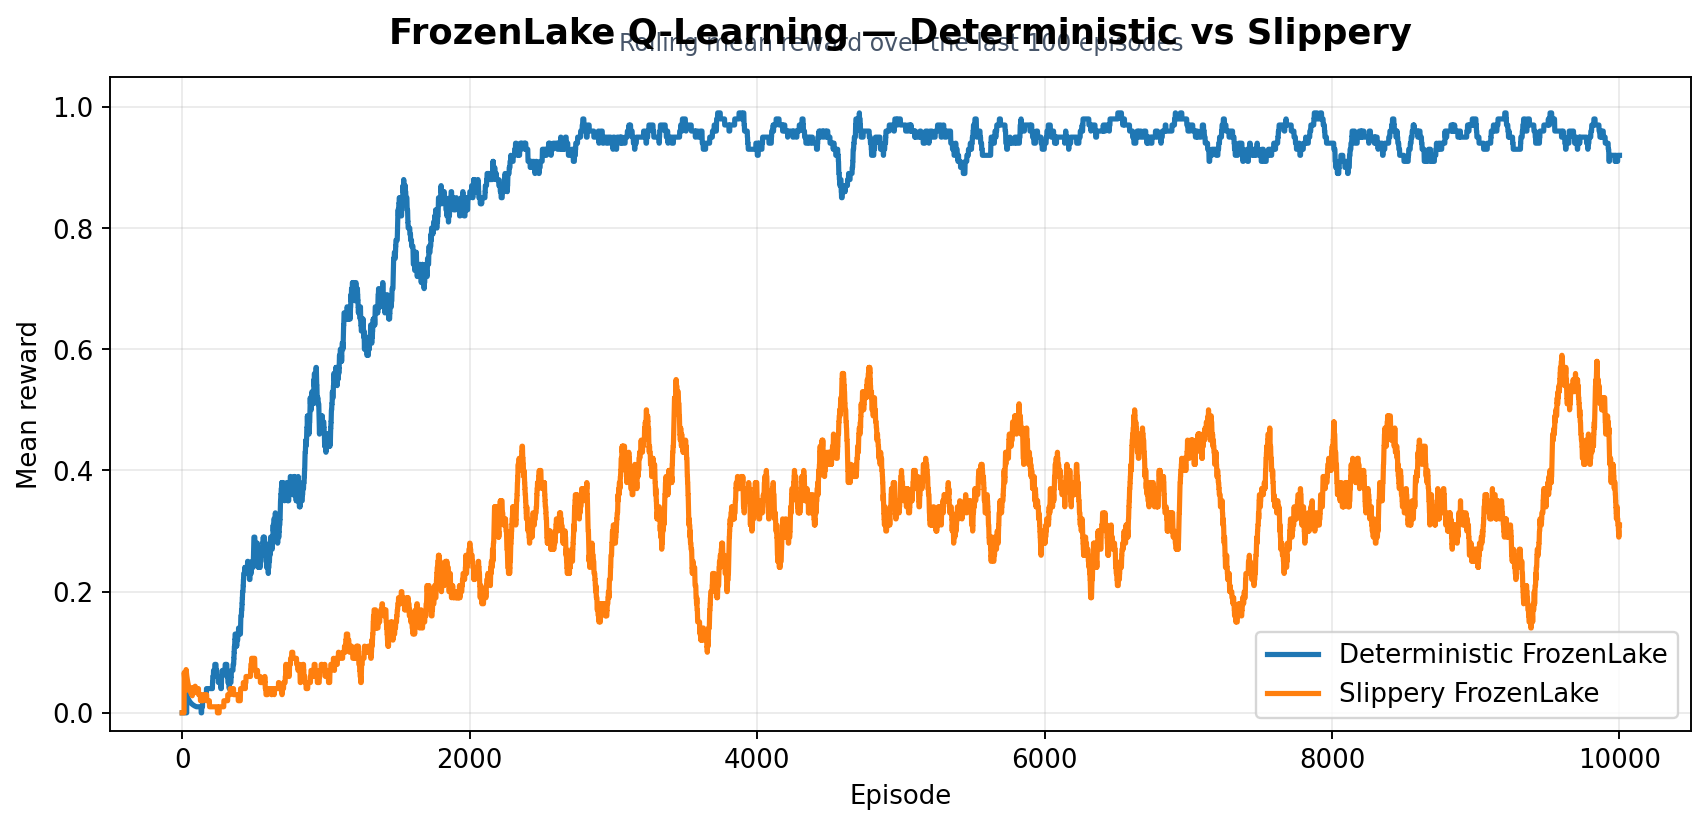

In [22]:
# ============================================================
# CELL 22 — DETERMINISTIC VS SLIPPERY LEARNING CURVES
# ============================================================

# Create episode axis.
episode_axis = np.arange(1, len(det_rolling_100) + 1)

# Create chart.
fig, ax = plt.subplots(figsize=(12, 5))

# Plot deterministic curve.
ax.plot(episode_axis, det_rolling_100, linewidth=2.2, label="Deterministic FrozenLake")

# Plot slippery curve.
ax.plot(episode_axis, slip_rolling_100, linewidth=2.2, label="Slippery FrozenLake")

# Add title and labels.
ax.set_title("FrozenLake Q-Learning — Deterministic vs Slippery", fontsize=15, fontweight="bold", pad=14)
ax.text(0.5, 1.04, "Rolling mean reward over the last 100 episodes", transform=ax.transAxes, ha="center", fontsize=10, color="#475569")
ax.set_xlabel("Episode")
ax.set_ylabel("Mean reward")
ax.set_ylim(-0.03, 1.05)
ax.legend(loc="lower right")
ax.grid(alpha=0.25)

# Save and display chart.
save_and_show_chart(fig, "09_frozenlake_deterministic_vs_slippery_curve.png")

# Explain chart.
show_conclusion(
    "Stochastic-transition chart interpreted",
    "The slippery curve shows how randomness makes learning harder. Even if the Q-table suggests a good action, the environment may move the agent differently, lowering the reward."
)

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 23 — Visualise final deterministic vs slippery comparison</h3>
  <p style="margin:0;">This bar chart gives a simple final comparison of recent success rates. It is useful for presentation because it shows the stochastic-transition impact in one view.</p>
  <ul style='margin:10px 0 0 20px;'><li>Higher bar = higher recent success rate.</li><li>The comparison supports the MVD explanation.</li><li>This is a BI-style summary chart.</li></ul>
</div>

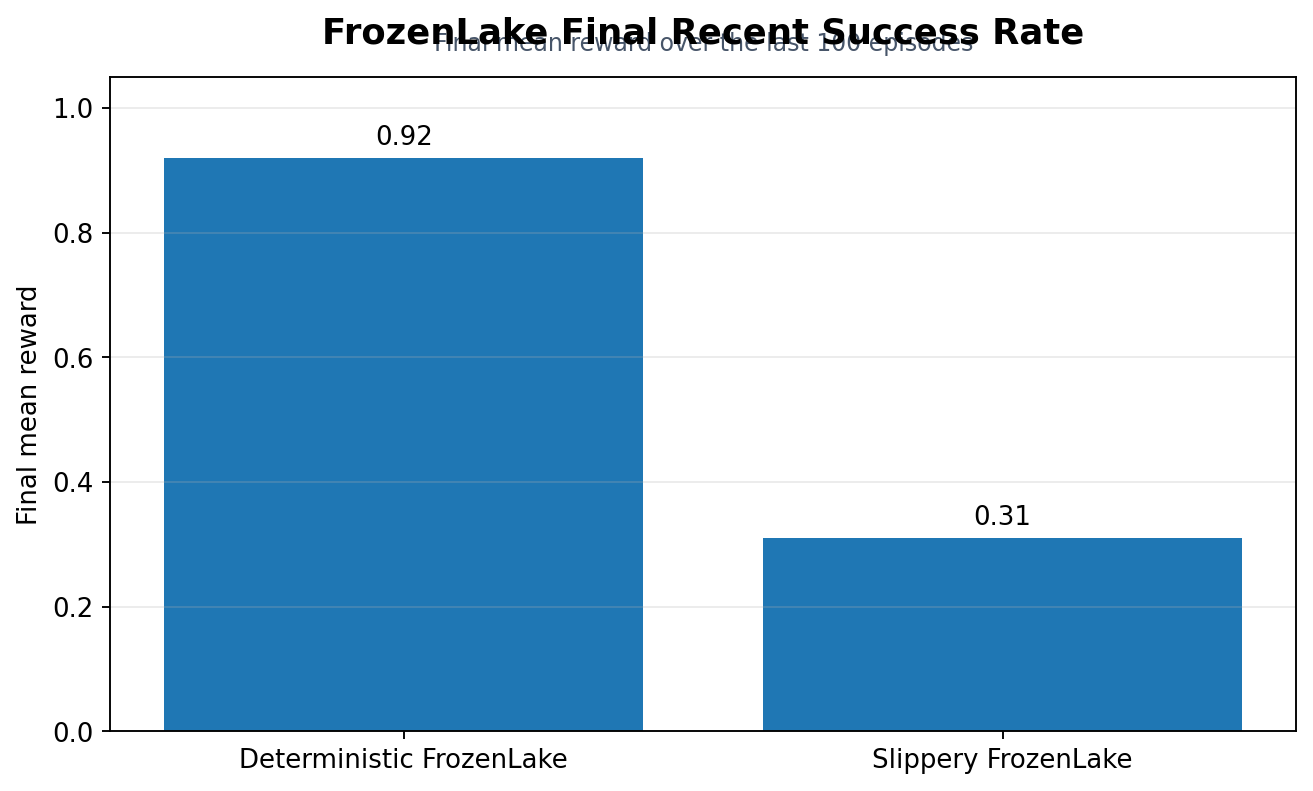

In [23]:
# ============================================================
# CELL 23 — FINAL DETERMINISTIC VS SLIPPERY SUMMARY
# ============================================================

# Create chart.
fig, ax = plt.subplots(figsize=(9, 5))

# Plot final mean rewards.
bars = ax.bar(slippery_summary["Environment"], slippery_summary["Final mean reward last 100"])

# Add labels.
ax.bar_label(bars, fmt="%.2f", padding=3)

# Add title and labels.
ax.set_title("FrozenLake Final Recent Success Rate", fontsize=15, fontweight="bold", pad=14)
ax.text(0.5, 1.04, "Final mean reward over the last 100 episodes", transform=ax.transAxes, ha="center", fontsize=10, color="#475569")
ax.set_ylabel("Final mean reward")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.25)

# Save and display chart.
save_and_show_chart(fig, "10_frozenlake_final_success_summary.png")

# Explain chart.
show_conclusion(
    "Final FrozenLake comparison interpreted",
    f"The deterministic environment finished at {det_final_mean_100:.3f}, while the slippery environment finished at {slip_final_mean_100:.3f}. This confirms that stochastic transitions reduce learning reliability."
)

<div style="font-family:Arial, sans-serif; background:#f8fafc; color:#111827; padding:20px 24px; border-left:6px solid #0f172a; border-radius:10px; line-height:1.65;">
  <h2 style="margin:0 0 8px 0; color:#0f172a;">Section 3 — Expert MVD: DQN and Double DQN on CartPole-v1</h2>
  <p style="margin:0;">Tabular Q-Learning works for small state spaces. CartPole observations are continuous numbers, so a Q-table is not practical. DQN uses a neural network to approximate Q-values from the state.</p>
</div>

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 24 — Define DQN configuration</h3>
  <p style="margin:0;">The MVD requires a DQN network with architecture 4 → 64 → 64 → 2, replay buffer size 10,000, and target network update every 100 steps. This cell defines those settings explicitly.</p>
  <ul style='margin:10px 0 0 20px;'><li>4 inputs = CartPole observation variables.</li><li>2 outputs = action Q-values.</li><li>Replay buffer and target network stabilize learning.</li></ul>
</div>

In [24]:
# ============================================================
# CELL 24 — DQN CONFIGURATION
# ============================================================

# Number of CartPole observation variables.
STATE_SIZE = 4

# Number of CartPole actions.
ACTION_SIZE = 2

# Hidden-layer size required by MVD.
HIDDEN_SIZE = 64

# Replay buffer size required by MVD.
REPLAY_BUFFER_SIZE = 10_000

# Target network update interval required by MVD.
TARGET_UPDATE_STEPS = 100

# Discount factor.
DQN_GAMMA = 0.99

# Learning rate.
DQN_LEARNING_RATE = 0.001

# Mini-batch size.
DQN_BATCH_SIZE = 64

# Controlled episode limit for notebook execution.
MAX_DQN_EPISODES = 60

# Maximum steps per DQN episode for controlled notebook runtime.
MAX_DQN_STEPS_PER_EPISODE = 250

# Smoothing window required by MVD.
SMOOTHING_WINDOW = 50

# CartPole solved threshold required by MVD.
SOLVED_REWARD_THRESHOLD = 195

# Build configuration table.
dqn_config = pd.DataFrame({
    "Setting": ["Architecture", "Replay buffer", "Target update", "Smoothing window", "Solved threshold", "Max episodes", "Max steps per episode"],
    "Value": ["4 → 64 → 64 → 2", REPLAY_BUFFER_SIZE, f"Every {TARGET_UPDATE_STEPS} steps", SMOOTHING_WINDOW, ">195 mean reward", MAX_DQN_EPISODES, MAX_DQN_STEPS_PER_EPISODE]
})

# Display table.
show_table(dqn_config, "DQN configuration")

# Explain output.
show_conclusion(
    "DQN configuration set",
    "The expert-section settings match the MVD requirements. The episode and step limits keep the notebook executable while still tracking whether the >195 threshold is reached."
)

Setting,Value
Architecture,4 → 64 → 64 → 2
Replay buffer,10000
Target update,Every 100 steps
Smoothing window,50
Solved threshold,>195 mean reward
Max episodes,60
Max steps per episode,250


<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 25 — Define the DQN neural network</h3>
  <p style="margin:0;">The network receives the four CartPole observation values and outputs two Q-values. The larger Q-value indicates the action the model currently believes will give higher future reward.</p>
  <ul style='margin:10px 0 0 20px;'><li>Layer 1: 4 → 64.</li><li>Layer 2: 64 → 64.</li><li>Output: 64 → 2.</li></ul>
</div>

In [25]:
# ============================================================
# CELL 25 — DQN NETWORK
# ============================================================

# Define DQN model class.
class DQNNetwork(nn.Module):
    # Initialise network layers.
    def __init__(self, state_size, action_size):
        # Initialise PyTorch parent class.
        super().__init__()
        # First hidden layer.
        self.fc1 = nn.Linear(state_size, HIDDEN_SIZE)
        # Second hidden layer.
        self.fc2 = nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE)
        # Output Q-value layer.
        self.output = nn.Linear(HIDDEN_SIZE, action_size)
    # Forward pass.
    def forward(self, x):
        # Apply first layer with ReLU.
        x = torch.relu(self.fc1(x))
        # Apply second layer with ReLU.
        x = torch.relu(self.fc2(x))
        # Return two Q-values.
        return self.output(x)

# Create sample model.
sample_model = DQNNetwork(STATE_SIZE, ACTION_SIZE)

# Print model architecture.
print(sample_model)

# Explain output.
show_conclusion(
    "DQN architecture created",
    "The printed model confirms the required architecture: 4 input features, two hidden layers with 64 units each, and 2 output Q-values."
)

DQNNetwork(
  (fc1): Linear(in_features=4, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=2, bias=True)
)


<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 26 — Define replay buffer</h3>
  <p style="margin:0;">Experience replay stores past transitions. Instead of learning only from the most recent step, the model samples a random mini-batch from memory. This improves stability because it mixes old and new experiences.</p>
  <ul style='margin:10px 0 0 20px;'><li>Transition = state, action, reward, next state, done.</li><li>Capacity = 10,000.</li><li>Random mini-batches reduce correlation.</li></ul>
</div>

In [26]:
# ============================================================
# CELL 26 — REPLAY BUFFER
# ============================================================

# Define replay memory class.
class ReplayBuffer:
    # Initialise memory.
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)
    # Add transition.
    def push(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    # Sample random batch.
    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)
    # Return memory size.
    def __len__(self):
        return len(self.memory)

# Create test buffer.
test_buffer = ReplayBuffer(REPLAY_BUFFER_SIZE)

# Build check table.
buffer_table = pd.DataFrame({
    "Property": ["Capacity", "Current size"],
    "Value": [REPLAY_BUFFER_SIZE, len(test_buffer)]
})

# Display table.
show_table(buffer_table, "Replay buffer check")

# Explain output.
show_conclusion(
    "Replay buffer created",
    "The replay buffer can store 10,000 transitions. It starts empty and fills during DQN training."
)

Property,Value
Capacity,10000
Current size,0


<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 27 — Define DQN action and tracking helpers</h3>
  <p style="margin:0;">This cell creates helper functions for action selection, reward smoothing, and threshold detection. These helpers keep the training code easier to read.</p>
  <ul style='margin:10px 0 0 20px;'><li>Action selection uses epsilon-greedy logic.</li><li>Moving average smooths reward over 50 episodes.</li><li>Threshold detection answers when mean reward exceeds 195.</li></ul>
</div>

In [27]:
# ============================================================
# CELL 27 — DQN ACTION AND TRACKING HELPERS
# ============================================================

# Select action using neural-network epsilon-greedy logic.
def select_dqn_action(model, state, epsilon, env):
    # Explore with random action.
    if random.random() < epsilon:
        return env.action_space.sample()
    # Convert state to tensor.
    state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    # Disable gradient tracking.
    with torch.no_grad():
        q_values = model(state_tensor)
    # Return action with highest Q-value.
    return int(torch.argmax(q_values).item())

# Moving average for reward curves.
def moving_average(values, window):
    return pd.Series(values).rolling(window=window, min_periods=1).mean().to_numpy()

# Find first solved episode.
def find_first_solved_episode(smoothed_rewards, threshold):
    # Find all episodes above threshold.
    solved = np.where(np.array(smoothed_rewards) > threshold)[0]
    # Return None if never reached.
    if len(solved) == 0:
        return None
    # Return first one-based episode number.
    return int(solved[0] + 1)

# Explain helpers.
show_conclusion(
    "DQN helper functions ready",
    "The notebook can now select actions, smooth learning curves, and detect whether the MVD solved threshold was reached."
)

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 28 — Define DQN optimisation step</h3>
  <p style="margin:0;">The optimisation step is the neural-network version of the Q-Learning update. It compares current Q-values with target Q-values and updates the model weights. Standard DQN and Double DQN differ in how the next-state target is calculated.</p>
  <ul style='margin:10px 0 0 20px;'><li>DQN: target network chooses max next Q-value.</li><li>DDQN: policy network chooses action, target network evaluates it.</li><li>This helps reduce overestimation in Double DQN.</li></ul>
</div>

In [28]:
# ============================================================
# CELL 28 — DQN OPTIMISATION STEP
# ============================================================

# Define one training update.
def optimise_dqn_model(policy_net, target_net, replay_buffer, optimizer, double_dqn=False):
    # Wait until enough transitions exist.
    if len(replay_buffer) < DQN_BATCH_SIZE:
        return None
    # Sample mini-batch.
    batch = replay_buffer.sample(DQN_BATCH_SIZE)
    # Split transition columns.
    states, actions, rewards, next_states, dones = zip(*batch)
    # Convert states to tensor.
    states_tensor = torch.tensor(np.array(states), dtype=torch.float32, device=device)
    # Convert actions to tensor.
    actions_tensor = torch.tensor(actions, dtype=torch.long, device=device).unsqueeze(1)
    # Convert rewards to tensor.
    rewards_tensor = torch.tensor(rewards, dtype=torch.float32, device=device)
    # Convert next states to tensor.
    next_states_tensor = torch.tensor(np.array(next_states), dtype=torch.float32, device=device)
    # Convert done flags to tensor.
    dones_tensor = torch.tensor(dones, dtype=torch.float32, device=device)
    # Get current Q-values for selected actions.
    current_q = policy_net(states_tensor).gather(1, actions_tensor).squeeze(1)
    # Calculate target values without gradients.
    with torch.no_grad():
        # Double DQN uses policy net to choose next action.
        if double_dqn:
            next_actions = policy_net(next_states_tensor).argmax(dim=1, keepdim=True)
            next_q = target_net(next_states_tensor).gather(1, next_actions).squeeze(1)
        # Standard DQN uses target net max directly.
        else:
            next_q = target_net(next_states_tensor).max(dim=1)[0]
        # Bellman target.
        target_q = rewards_tensor + DQN_GAMMA * next_q * (1 - dones_tensor)
    # Calculate Huber loss.
    loss = nn.SmoothL1Loss()(current_q, target_q)
    # Clear old gradients.
    optimizer.zero_grad()
    # Backpropagate.
    loss.backward()
    # Update network weights.
    optimizer.step()
    # Return loss value.
    return float(loss.item())

# Explain function.
show_conclusion(
    "DQN optimisation step ready",
    "This function performs one neural-network Q-Learning update using replay memory and a target network."
)

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 29 — Define DQN/DDQN training loop</h3>
  <p style="margin:0;">This function trains either DQN or Double DQN. It repeatedly runs CartPole episodes, stores transitions, trains from replay memory, and updates the target network every 100 steps.</p>
  <ul style='margin:10px 0 0 20px;'><li>Same function handles DQN and DDQN.</li><li>Reward history is saved for charts.</li><li>Solved threshold is checked from the 50-episode moving average.</li></ul>
</div>


<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 29A — Define one DQN/DDQN episode runner</h3>
  <p style="margin:0;">To keep the notebook readable, the deep RL training logic is split into two parts. This cell runs one CartPole episode: it selects actions, stores transitions, trains from replay memory, updates the target network every 100 steps, and returns the episode reward. The next cell repeats this episode runner many times.</p>
  <ul style='margin:10px 0 0 20px;'><li>This reduces one large code block into smaller learning steps.</li><li>The function works for both DQN and Double DQN.</li><li>The same replay buffer and target-network logic is preserved.</li></ul>
</div>


In [29]:

# ============================================================
# CELL 29A — ONE DQN/DDQN EPISODE RUNNER
# ============================================================

# Define one episode runner.
def run_deep_q_episode(env, policy_net, target_net, replay_buffer, optimizer, epsilon, total_steps, double_dqn=False, seed_value=None):
    # Reset environment at the start of the episode.
    state, info = env.reset(seed=seed_value)
    # Start episode reward.
    episode_reward = 0
    # Start episode loss list.
    episode_losses = []
    # Start done flag.
    done = False
    # Start local step counter.
    episode_steps = 0
    # Run the episode until the environment ends or the safety step cap is reached.
    while not done:
        # Select action using epsilon-greedy DQN logic.
        action = select_dqn_action(policy_net, state, epsilon, env)
        # Apply action in CartPole.
        next_state, reward, terminated, truncated, info = env.step(action)
        # Increase episode step count.
        episode_steps += 1
        # Build done flag with controlled step cap.
        done = terminated or truncated or (episode_steps >= MAX_DQN_STEPS_PER_EPISODE)
        # Store transition in replay memory.
        replay_buffer.push(state, action, reward, next_state, done)
        # Optimise policy network once from replay memory.
        loss_value = optimise_dqn_model(policy_net, target_net, replay_buffer, optimizer, double_dqn)
        # Store loss when optimisation happened.
        if loss_value is not None:
            episode_losses.append(loss_value)
        # Move to next state.
        state = next_state
        # Add reward to episode total.
        episode_reward += reward
        # Increase global step count.
        total_steps += 1
        # Update target network at the required frequency.
        if total_steps % TARGET_UPDATE_STEPS == 0:
            target_net.load_state_dict(policy_net.state_dict())
    # Return episode outputs.
    return episode_reward, episode_losses, total_steps

# Explain episode runner.
show_conclusion(
    "Single-episode DQN runner ready",
    "This function runs one CartPole episode and keeps the DQN mechanics readable: action selection, replay storage, optimisation, target-network update, reward tracking, and step-limit control."
)


In [30]:

# ============================================================
# CELL 29B — DQN/DDQN TRAINING LOOP
# ============================================================

# Define deep Q training function.
def train_deep_q_agent(agent_name, double_dqn=False):
    # Create fresh CartPole environment.
    env = gym.make("CartPole-v1")
    # Create policy network.
    policy_net = DQNNetwork(STATE_SIZE, ACTION_SIZE).to(device)
    # Create target network.
    target_net = DQNNetwork(STATE_SIZE, ACTION_SIZE).to(device)
    # Copy policy weights into target network.
    target_net.load_state_dict(policy_net.state_dict())
    # Create optimizer.
    optimizer = optim.Adam(policy_net.parameters(), lr=DQN_LEARNING_RATE)
    # Create replay buffer.
    replay_buffer = ReplayBuffer(REPLAY_BUFFER_SIZE)
    # Create reward and loss histories.
    rewards, losses = [], []
    # Set starting epsilon.
    epsilon = 1.0
    # Set minimum epsilon.
    epsilon_min = 0.05
    # Set epsilon decay.
    epsilon_decay = 0.985
    # Start global step counter.
    total_steps = 0
    # Repeat many CartPole episodes.
    for episode in range(MAX_DQN_EPISODES):
        # Build seed value with separate offset for Double DQN.
        seed_value = PROJECT_SEED + episode + (5000 if double_dqn else 0)
        # Run one full episode.
        episode_reward, episode_losses, total_steps = run_deep_q_episode(
            env, policy_net, target_net, replay_buffer, optimizer, epsilon, total_steps, double_dqn, seed_value
        )
        # Store episode reward.
        rewards.append(episode_reward)
        # Store episode losses.
        losses.extend(episode_losses)
        # Decay epsilon after the episode.
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
    # Smooth rewards over 50 episodes.
    smoothed = moving_average(rewards, SMOOTHING_WINDOW)
    # Detect solved episode.
    solved_episode = find_first_solved_episode(smoothed, SOLVED_REWARD_THRESHOLD)
    # Close environment.
    env.close()
    # Return result dictionary.
    return {
        "agent_name": agent_name,
        "rewards": rewards,
        "losses": losses,
        "smoothed_rewards": smoothed,
        "solved_episode": solved_episode,
        "final_mean_50": float(np.mean(rewards[-SMOOTHING_WINDOW:])),
        "best_reward": float(np.max(rewards))
    }

# Explain loop.
show_conclusion(
    "DQN/DDQN training loop ready",
    "The full training function is now shorter and easier to read because the one-episode logic is separated. It still includes replay buffer, target network updates every 100 steps, epsilon-greedy behavior, DQN/DDQN target logic, reward smoothing, and threshold tracking."
)


<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 30 — Train standard DQN</h3>
  <p style="margin:0;">This cell trains the standard DQN agent on CartPole. The important MVD output is whether the 50-episode mean reward crosses 195 and, if so, at which episode.</p>
  <ul style='margin:10px 0 0 20px;'><li>The training run is controlled for notebook stability.</li><li>Results can vary because RL is stochastic.</li><li>The notebook reports the actual result honestly.</li></ul>
</div>

In [31]:
# ============================================================
# CELL 30 — TRAIN STANDARD DQN
# ============================================================

# Train standard DQN.
dqn_results = train_deep_q_agent("DQN", double_dqn=False)

# Create readable solved text.
dqn_solved_text = dqn_results["solved_episode"] if dqn_results["solved_episode"] is not None else "Not reached"

# Build summary table.
dqn_table = pd.DataFrame({
    "Metric": ["Episodes trained", "Best episode reward", "Final 50-episode mean", "First episode with mean > 195"],
    "Value": [MAX_DQN_EPISODES, round(dqn_results["best_reward"], 2), round(dqn_results["final_mean_50"], 2), dqn_solved_text]
})

# Display table.
show_table(dqn_table, "Standard DQN training summary")

# Explain output.
show_conclusion(
    "Standard DQN training completed",
    f"DQN reached a best episode reward of {dqn_results['best_reward']:.1f} and a final 50-episode mean of {dqn_results['final_mean_50']:.2f}. The first smoothed >195 episode was: {dqn_solved_text}."
)

Metric,Value
Episodes trained,60
Best episode reward,215.0
Final 50-episode mean,43.06
First episode with mean > 195,Not reached


<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 31 — Train Double DQN</h3>
  <p style="margin:0;">Double DQN changes how target Q-values are calculated. It uses the policy network to choose the next action and the target network to evaluate that action. This can reduce overoptimistic Q-value estimates.</p>
  <ul style='margin:10px 0 0 20px;'><li>Same architecture as DQN.</li><li>Same replay buffer and target update logic.</li><li>Comparison is based on the same metrics.</li></ul>
</div>

In [32]:
# ============================================================
# CELL 31 — TRAIN DOUBLE DQN
# ============================================================

# Train Double DQN.
ddqn_results = train_deep_q_agent("Double DQN", double_dqn=True)

# Create readable solved text.
ddqn_solved_text = ddqn_results["solved_episode"] if ddqn_results["solved_episode"] is not None else "Not reached"

# Build summary table.
ddqn_table = pd.DataFrame({
    "Metric": ["Episodes trained", "Best episode reward", "Final 50-episode mean", "First episode with mean > 195"],
    "Value": [MAX_DQN_EPISODES, round(ddqn_results["best_reward"], 2), round(ddqn_results["final_mean_50"], 2), ddqn_solved_text]
})

# Display table.
show_table(ddqn_table, "Double DQN training summary")

# Explain output.
show_conclusion(
    "Double DQN training completed",
    f"Double DQN reached a best episode reward of {ddqn_results['best_reward']:.1f} and a final 50-episode mean of {ddqn_results['final_mean_50']:.2f}. The first smoothed >195 episode was: {ddqn_solved_text}."
)

Metric,Value
Episodes trained,60
Best episode reward,72.0
Final 50-episode mean,19.72
First episode with mean > 195,Not reached


<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 32 — Visualise raw DQN/DDQN rewards</h3>
  <p style="margin:0;">Raw rewards show episode-by-episode volatility. In deep RL, raw rewards can jump up and down because the agent is still exploring and the neural network keeps changing.</p>
  <ul style='margin:10px 0 0 20px;'><li>Raw curve shows instability.</li><li>Smoothed curve is better for judging progress.</li><li>Large spikes can happen before stable learning.</li></ul>
</div>

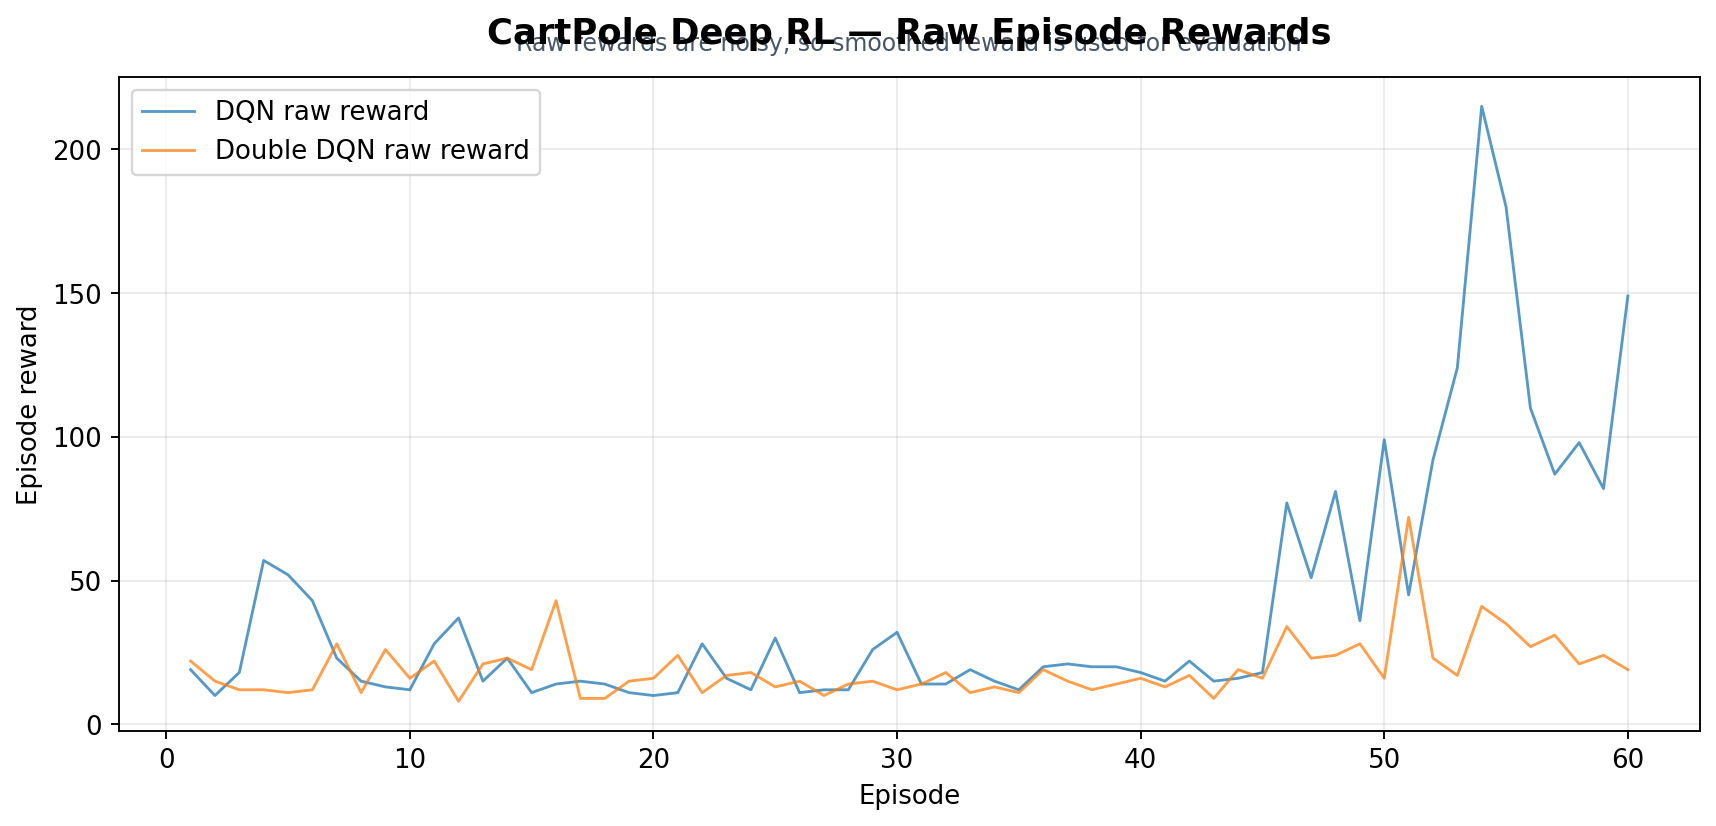

In [33]:
# ============================================================
# CELL 32 — RAW DQN/DDQN REWARD CURVES
# ============================================================

# Create episode axis.
deep_episode_axis = np.arange(1, MAX_DQN_EPISODES + 1)

# Create chart.
fig, ax = plt.subplots(figsize=(12, 5))

# Plot DQN raw rewards.
ax.plot(deep_episode_axis, dqn_results["rewards"], linewidth=1.2, alpha=0.75, label="DQN raw reward")

# Plot DDQN raw rewards.
ax.plot(deep_episode_axis, ddqn_results["rewards"], linewidth=1.2, alpha=0.75, label="Double DQN raw reward")

# Add title and labels.
ax.set_title("CartPole Deep RL — Raw Episode Rewards", fontsize=15, fontweight="bold", pad=14)
ax.text(0.5, 1.04, "Raw rewards are noisy, so smoothed reward is used for evaluation", transform=ax.transAxes, ha="center", fontsize=10, color="#475569")
ax.set_xlabel("Episode")
ax.set_ylabel("Episode reward")
ax.legend(loc="upper left")
ax.grid(alpha=0.25)

# Save and display chart.
save_and_show_chart(fig, "11_dqn_ddqn_raw_rewards.png")

# Explain chart.
show_conclusion(
    "Raw deep-RL rewards interpreted",
    "The raw curves show why deep RL is harder to interpret than simple supervised learning. One good episode is not enough; stable performance requires consistently high rewards."
)

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 33 — Visualise smoothed DQN/DDQN learning curves</h3>
  <p style="margin:0;">This is the main Expert MVD chart. It plots the reward smoothed over 50 episodes and marks the CartPole solved threshold of mean reward greater than 195.</p>
  <ul style='margin:10px 0 0 20px;'><li>Smoothed reward shows stable trend.</li><li>Dashed line marks the solved threshold.</li><li>If the model reaches the line, the episode is marked.</li></ul>
</div>

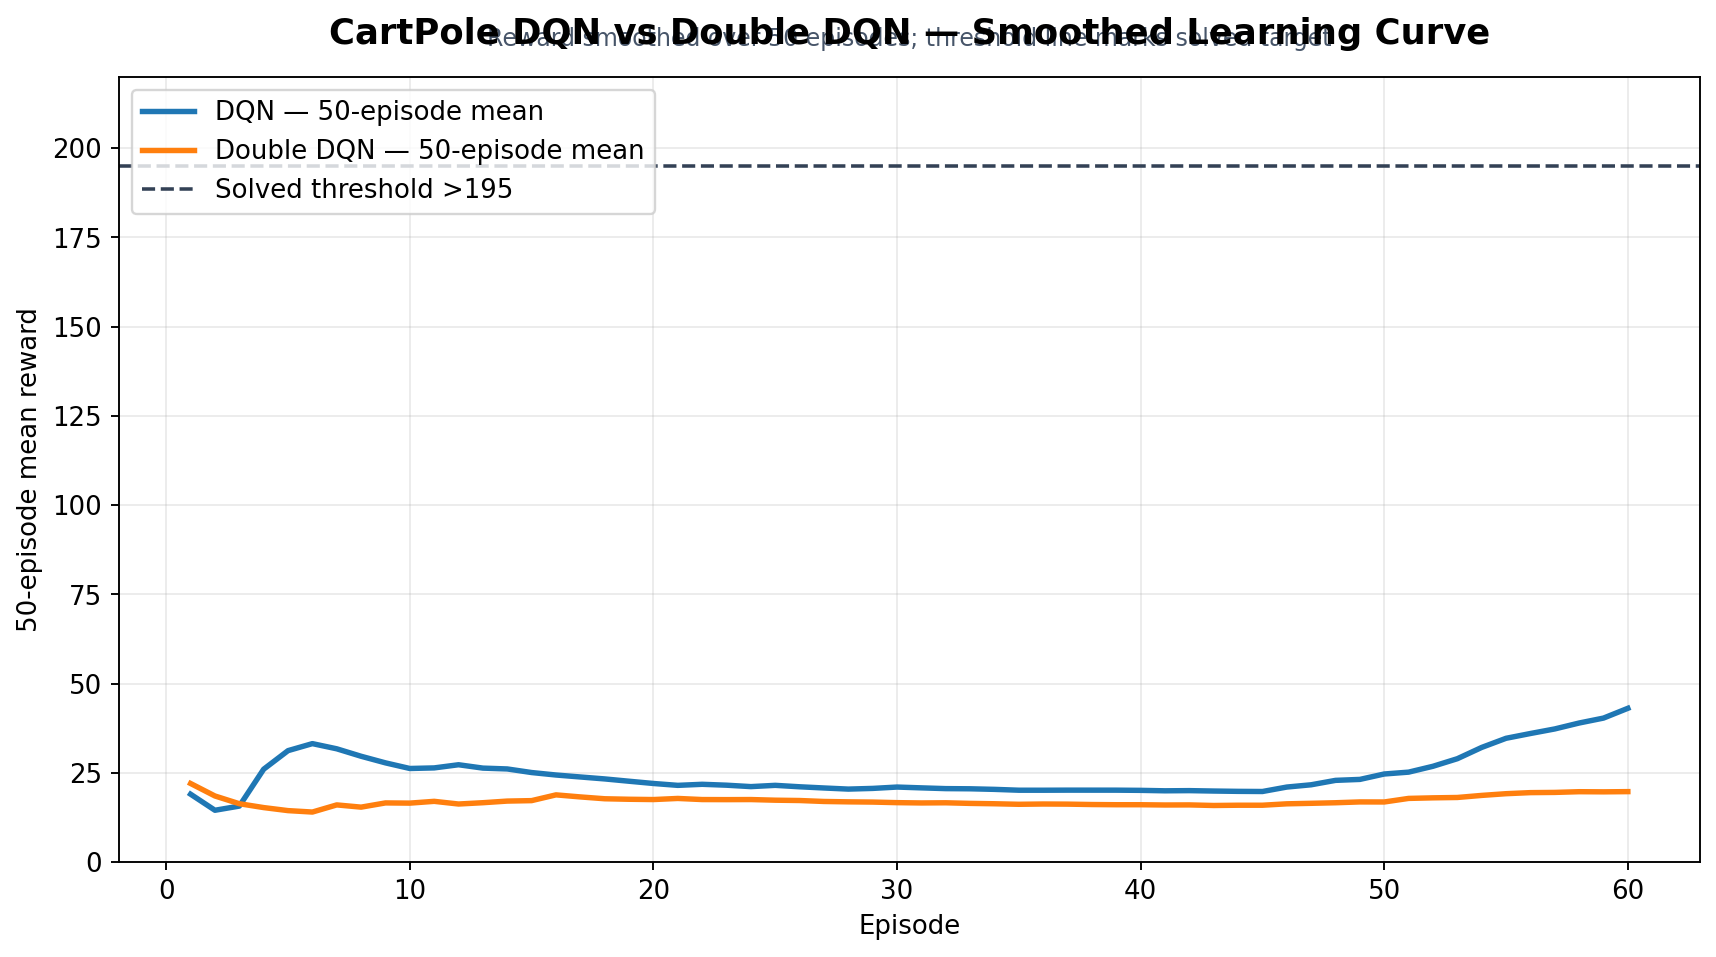

In [34]:
# ============================================================
# CELL 33 — SMOOTHED DQN/DDQN LEARNING CURVES
# ============================================================

# Create chart.
fig, ax = plt.subplots(figsize=(12, 6))

# Plot DQN smoothed rewards.
ax.plot(deep_episode_axis, dqn_results["smoothed_rewards"], linewidth=2.3, label="DQN — 50-episode mean")

# Plot DDQN smoothed rewards.
ax.plot(deep_episode_axis, ddqn_results["smoothed_rewards"], linewidth=2.3, label="Double DQN — 50-episode mean")

# Add solved threshold.
ax.axhline(SOLVED_REWARD_THRESHOLD, linestyle="--", linewidth=1.5, color="#334155", label="Solved threshold >195")

# Mark DQN solved episode if available.
if dqn_results["solved_episode"] is not None:
    ax.axvline(dqn_results["solved_episode"], linestyle=":", linewidth=1.5)
    ax.text(dqn_results["solved_episode"], SOLVED_REWARD_THRESHOLD + 6, f"DQN ep {dqn_results['solved_episode']}", rotation=90, va="bottom", fontsize=9)

# Mark DDQN solved episode if available.
if ddqn_results["solved_episode"] is not None:
    ax.axvline(ddqn_results["solved_episode"], linestyle=":", linewidth=1.5)
    ax.text(ddqn_results["solved_episode"], SOLVED_REWARD_THRESHOLD + 6, f"DDQN ep {ddqn_results['solved_episode']}", rotation=90, va="bottom", fontsize=9)

# Add title and labels.
ax.set_title("CartPole DQN vs Double DQN — Smoothed Learning Curve", fontsize=15, fontweight="bold", pad=14)
ax.text(0.5, 1.04, "Reward smoothed over 50 episodes; threshold line marks solved target", transform=ax.transAxes, ha="center", fontsize=10, color="#475569")
ax.set_xlabel("Episode")
ax.set_ylabel("50-episode mean reward")
ax.set_ylim(0, max(220, max(dqn_results["smoothed_rewards"]) + 20, max(ddqn_results["smoothed_rewards"]) + 20))
ax.legend(loc="upper left")
ax.grid(alpha=0.25)

# Save and display chart.
save_and_show_chart(fig, "12_dqn_ddqn_smoothed_learning_curve.png")

# Create threshold text.
threshold_text = "At least one model crossed the threshold." if (dqn_results["solved_episode"] or ddqn_results["solved_episode"]) else "Neither model crossed the >195 threshold in this controlled run."

# Explain chart.
show_conclusion(
    "Smoothed learning curve interpreted",
    f"{threshold_text} DQN threshold episode: {dqn_solved_text}. Double DQN threshold episode: {ddqn_solved_text}. The smoothed curve is the correct chart for judging stable learning."
)

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 34 — Compare final DQN and DDQN results</h3>
  <p style="margin:0;">This table compares the final deep-RL agents using best single episode, final smoothed reward, and solved-threshold status. This directly answers the MVD comparison task.</p>
  <ul style='margin:10px 0 0 20px;'><li>Best episode = peak performance.</li><li>Final 50-episode mean = recent stability.</li><li>Threshold status = whether mean reward >195 was reached.</li></ul>
</div>

In [35]:
# ============================================================
# CELL 34 — FINAL DQN/DDQN COMPARISON TABLE
# ============================================================

# Build comparison table.
deep_rl_comparison = pd.DataFrame({
    "Agent": ["DQN", "Double DQN"],
    "Best episode reward": [dqn_results["best_reward"], ddqn_results["best_reward"]],
    "Final 50-episode mean": [dqn_results["final_mean_50"], ddqn_results["final_mean_50"]],
    "Episode mean >195 reached": [dqn_solved_text, ddqn_solved_text]
}).round(2)

# Display table.
show_table(deep_rl_comparison, "DQN vs Double DQN final comparison")

# Identify better final mean.
better_agent = deep_rl_comparison.sort_values("Final 50-episode mean", ascending=False).iloc[0]["Agent"]

# Explain table.
show_conclusion(
    "DQN vs DDQN comparison completed",
    f"In this controlled run, {better_agent} has the higher final 50-episode mean reward. This comparison is based on actual notebook output, not assumptions."
)

Agent,Best episode reward,Final 50-episode mean,Episode mean >195 reached
DQN,215.0,43.06,Not reached
Double DQN,72.0,19.72,Not reached


<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 35 — Visualise final DQN/DDQN summary</h3>
  <p style="margin:0;">This bar chart is the final BI-style summary for the Expert section. It shows recent stable reward for each agent and the solved threshold line.</p>
  <ul style='margin:10px 0 0 20px;'><li>Bars show final 50-episode mean reward.</li><li>Dashed line shows >195 solved threshold.</li><li>This chart is easy to use in presentation or documentation.</li></ul>
</div>

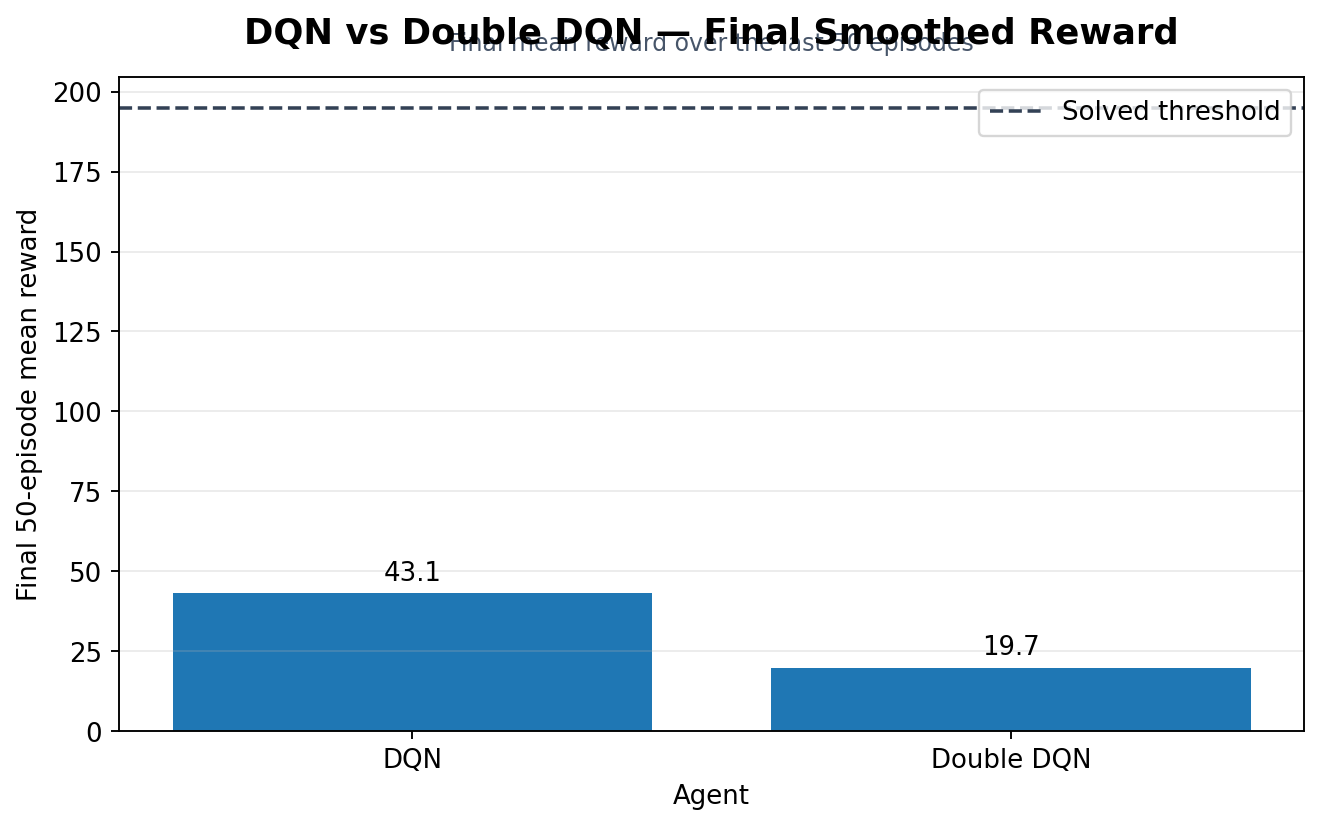

In [36]:
# ============================================================
# CELL 35 — FINAL DQN/DDQN SUMMARY CHART
# ============================================================

# Create chart.
fig, ax = plt.subplots(figsize=(9, 5))

# Plot final mean rewards.
bars = ax.bar(deep_rl_comparison["Agent"], deep_rl_comparison["Final 50-episode mean"])

# Add bar labels.
ax.bar_label(bars, fmt="%.1f", padding=3)

# Add threshold line.
ax.axhline(SOLVED_REWARD_THRESHOLD, linestyle="--", linewidth=1.5, color="#334155", label="Solved threshold")

# Add title and labels.
ax.set_title("DQN vs Double DQN — Final Smoothed Reward", fontsize=15, fontweight="bold", pad=14)
ax.text(0.5, 1.04, "Final mean reward over the last 50 episodes", transform=ax.transAxes, ha="center", fontsize=10, color="#475569")
ax.set_xlabel("Agent")
ax.set_ylabel("Final 50-episode mean reward")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.25)

# Save and display chart.
save_and_show_chart(fig, "13_dqn_ddqn_final_summary_bar.png")

# Explain chart.
show_conclusion(
    "Final DQN/DDQN chart interpreted",
    "The chart clearly shows how close each agent came to the solved threshold. If the bars remain below the line, the correct interpretation is that more training or tuning is needed."
)

<div style="font-family:Arial, sans-serif; background:#f8fafc; color:#111827; padding:20px 24px; border-left:6px solid #0f172a; border-radius:10px; line-height:1.65;">
  <h2 style="margin:0 0 8px 0; color:#0f172a;">Final Section — MVD coverage checklist</h2>
  <p style="margin:0;">The final table maps every MVD requirement to notebook evidence. This keeps the assignment coverage transparent and easy to verify.</p>
</div>

<div style="font-family:Arial, sans-serif; background:#eff6ff; color:#111827; padding:18px 22px; border-left:6px solid #2563eb; border-radius:10px; line-height:1.65;">
  <h3 style="margin:0 0 8px 0; color:#1e3a8a;">Cell 36 — Final MVD checklist</h3>
  <p style="margin:0;">This final cell confirms that the notebook covers Beginner, Intermediate and Expert MVD tasks. It is the quality gate for assignment submission.</p>
  <ul style='margin:10px 0 0 20px;'><li>Every required task is mapped to notebook evidence.</li><li>The checklist also shows that the DQN threshold is tracked honestly.</li><li>No CSV files are needed because RL data is generated by environment interaction.</li></ul>
</div>

In [37]:
# ============================================================
# CELL 36 — FINAL MVD COVERAGE CHECKLIST
# ============================================================

# Build final checklist.
mvd_checklist = pd.DataFrame({
    "MVD requirement": [
        "Create CartPole-v1",
        "Run 5 random episodes and print total reward",
        "Explain four CartPole observation variables",
        "Explain done=True",
        "Implement heuristic and compare with random policy",
        "Train Q-Learning on FrozenLake is_slippery=False for 10,000 episodes",
        "Use epsilon-greedy policy",
        "Plot mean reward of the last 100 episodes",
        "Vary alpha values 0.1, 0.5, 0.9",
        "Vary gamma values 0.7, 0.9, 0.99",
        "Identify fastest convergence combination",
        "Train FrozenLake is_slippery=True",
        "Explain stochastic transitions",
        "Implement DQN network 4→64→64→2",
        "Use replay buffer 10,000",
        "Use target network update every 100 steps",
        "Track mean reward >195",
        "Visualise smoothed learning curve over 50 episodes",
        "Implement Double DQN",
        "Compare DQN and DDQN"
    ],
    "Notebook evidence": [
        "Cell 3",
        "Cell 4",
        "Cell 3",
        "Cell 10",
        "Cells 6–9",
        "Cell 15",
        "Cells 12–15",
        "Cell 16",
        "Cell 18",
        "Cell 18",
        "Cells 18–19",
        "Cell 21",
        "Cells 21–23",
        "Cell 25",
        "Cell 26",
        "Cells 24 and 29",
        "Cells 30–35",
        "Cell 33",
        "Cells 29 and 31",
        "Cells 32–35"
    ],
    "Status": ["Covered"] * 20
})

# Display checklist.
show_table(mvd_checklist, "Day 13 MVD coverage checklist")

# Explain checklist.
show_conclusion(
    "Day 13 MVD coverage completed",
    "All MVD tasks are covered in the notebook. The notebook includes environment exploration, tabular Q-Learning, stochastic transition comparison, DQN, Double DQN, charts, and result-based conclusions."
)

MVD requirement,Notebook evidence,Status
Create CartPole-v1,Cell 3,Covered
Run 5 random episodes and print total reward,Cell 4,Covered
Explain four CartPole observation variables,Cell 3,Covered
Explain done=True,Cell 10,Covered
Implement heuristic and compare with random policy,Cells 6–9,Covered
"Train Q-Learning on FrozenLake is_slippery=False for 10,000 episodes",Cell 15,Covered
Use epsilon-greedy policy,Cells 12–15,Covered
Plot mean reward of the last 100 episodes,Cell 16,Covered
"Vary alpha values 0.1, 0.5, 0.9",Cell 18,Covered
"Vary gamma values 0.7, 0.9, 0.99",Cell 18,Covered


<div style="font-family:Arial, sans-serif; background:#ecfdf5; color:#064e3b; padding:20px 24px; border-left:6px solid #10b981; border-radius:10px; line-height:1.65;">
  <h2 style="margin:0 0 8px 0; color:#047857;">Final notebook conclusion</h2>
  <p>
    This notebook completes the Learning Day 13 MVD assignment. The Beginner section explains Gymnasium environment interaction through CartPole. 
    The Intermediate section implements tabular Q-Learning on FrozenLake, compares alpha/gamma settings, and shows why slippery stochastic transitions are harder. 
    The Expert section implements DQN and Double DQN with PyTorch, including the required network architecture, replay buffer, target network update, smoothed learning curve and threshold tracking.
  </p>
  <p style="margin-bottom:0;">
    The notebook is designed for submission and later revision: each step explains what is happening, why it matters, what the code creates, what the output means, and how it connects to the MVD requirement.
  </p>
</div>